In [11]:
# ================================================================================
# Splitting training and test sets
# ================================================================================

import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns 
%matplotlib inline

data=pd.read_csv('WAGE2_2025_abridged.csv')

state=530088808+540338216+540527739+530800484+530356855 # replace this number with the sum of the student IDs for the members of your group

train = data.sample(frac=0.8, random_state=state)
test = data[data.index.isin(train.index)==False].copy() # Only for prediction

train=train.reset_index(drop = True)
test=test.reset_index(drop = True)


print(train.shape) #Check dimensions of training data
print(test.shape) #Check dimensions of test data


#Check if there are null values 
train.isnull().any()
test.isnull().any()


#Drop null values
train=train.dropna()    
test=test.dropna()     

print(train.shape)        #Training data original: 733, after cleaning: 531, change = 202
print(test.shape)         #Test data original: 183, after cleaning: 124, change = 59

#Total change: 202 + 59 = 261

(733, 17)
(183, 17)
(531, 17)
(124, 17)


### **Problems with data cleaning and solution**

Data cleaning problems: 

1. Selectivity problem: when data are missing but not randomly. 
2. Simple diagnostics: check distribution of full sample vs. dropped rows samples 
=> Look at the distribution of response variables

# **Task 1: Exploratory analysis**

The original data matrix contains 733 rows for training data, 183 rows for test data, and 17 columns for both. 

We realize that there are rows with null values, so our decision is to first clean the data through dropping all the rows with at least 1 null value. After cleaning, we retained 531 observations for the training data and 124 observations for the test data. 

This approach raises concerns in data loss and statistical power as after reduction only around 2/3 of the original data remain (total 655 rows). Nevertheless, through this method, we aim to keep data reliability, avoid introducing bias or analysis errors, and avoid false assumptions. We believe that the 655 remaining data points can provide reasonable information for meaningful analysis. 

In [12]:
train.head()

,wage,hours,IQ,KWW,educ,exper,tenure,age,married,black,south,urban,sibs,brthord,meduc,feduc,lwage
0,962,40,85,41,10,15,16,38,1,0,0,1,1,2.0,9.0,12.0,6.869014
2,894,40,104,35,18,7,10,35,1,0,1,0,7,8.0,9.0,8.0,6.795706
3,1250,40,92,42,16,10,11,32,0,0,1,1,1,1.0,12.0,10.0,7.130899
4,550,46,95,44,12,18,15,35,1,0,0,1,1,1.0,12.0,11.0,6.309918
5,600,40,114,36,16,5,4,30,1,0,1,1,2,1.0,12.0,12.0,6.396930


In [13]:
# Check the first 5 rows of data 
train.head()
test.head()

,wage,hours,IQ,KWW,educ,exper,tenure,age,married,black,south,urban,sibs,brthord,meduc,feduc,lwage
1,1318,38,119,24,16,7,2,28,1,0,0,1,3,1.0,10.0,10.0,7.183871
2,1792,40,118,47,16,9,9,34,1,0,0,1,1,1.0,12.0,12.0,7.491087
7,1274,40,106,35,13,11,12,31,1,0,0,1,0,1.0,15.0,12.0,7.149917
8,692,40,108,48,12,21,11,38,1,0,0,1,3,1.0,8.0,7.0,6.539586
10,808,60,109,47,13,14,12,38,1,0,0,1,2,2.0,12.0,10.0,6.694562


In [14]:
# EDA after cleaning
train.describe().round(2)
test.describe().round(2)

,wage,hours,IQ,KWW,educ,exper,tenure,age,married,black,south,urban,sibs,brthord,meduc,feduc,lwage
count,124.00,124.00,124.00,124.00,124.00,124.00,124.00,124.00,124.00,124.00,124.00,124.00,124.00,124.00,124.00,124.00,124.00
mean,957.16,44.08,100.48,35.73,13.55,11.23,7.94,32.84,0.90,0.09,0.27,0.70,2.69,2.02,10.54,10.26,6.78
std,401.36,6.83,14.22,7.55,2.16,4.23,5.15,2.89,0.31,0.29,0.44,0.46,2.08,1.29,2.94,3.25,0.43
min,200.00,32.00,66.00,19.00,9.00,1.00,0.00,28.00,0.00,0.00,0.00,0.00,0.00,1.00,1.00,3.00,5.30
25%,687.25,40.00,91.00,30.00,12.00,8.00,3.00,30.00,1.00,0.00,0.00,0.00,1.00,1.00,8.00,8.00,6.53
50%,943.50,40.00,99.50,36.50,12.00,11.00,8.00,32.50,1.00,0.00,0.00,1.00,2.00,2.00,12.00,10.00,6.85
75%,1154.25,48.00,109.25,41.00,16.00,14.25,12.00,35.00,1.00,0.00,1.00,1.00,3.00,2.00,12.00,12.00,7.05
max,2771.00,70.00,134.00,49.00,18.00,21.00,20.00,38.00,1.00,1.00,1.00,1.00,13.00,7.00,18.00,18.00,7.93


### **a. Distribution of numerical variables vs wage**

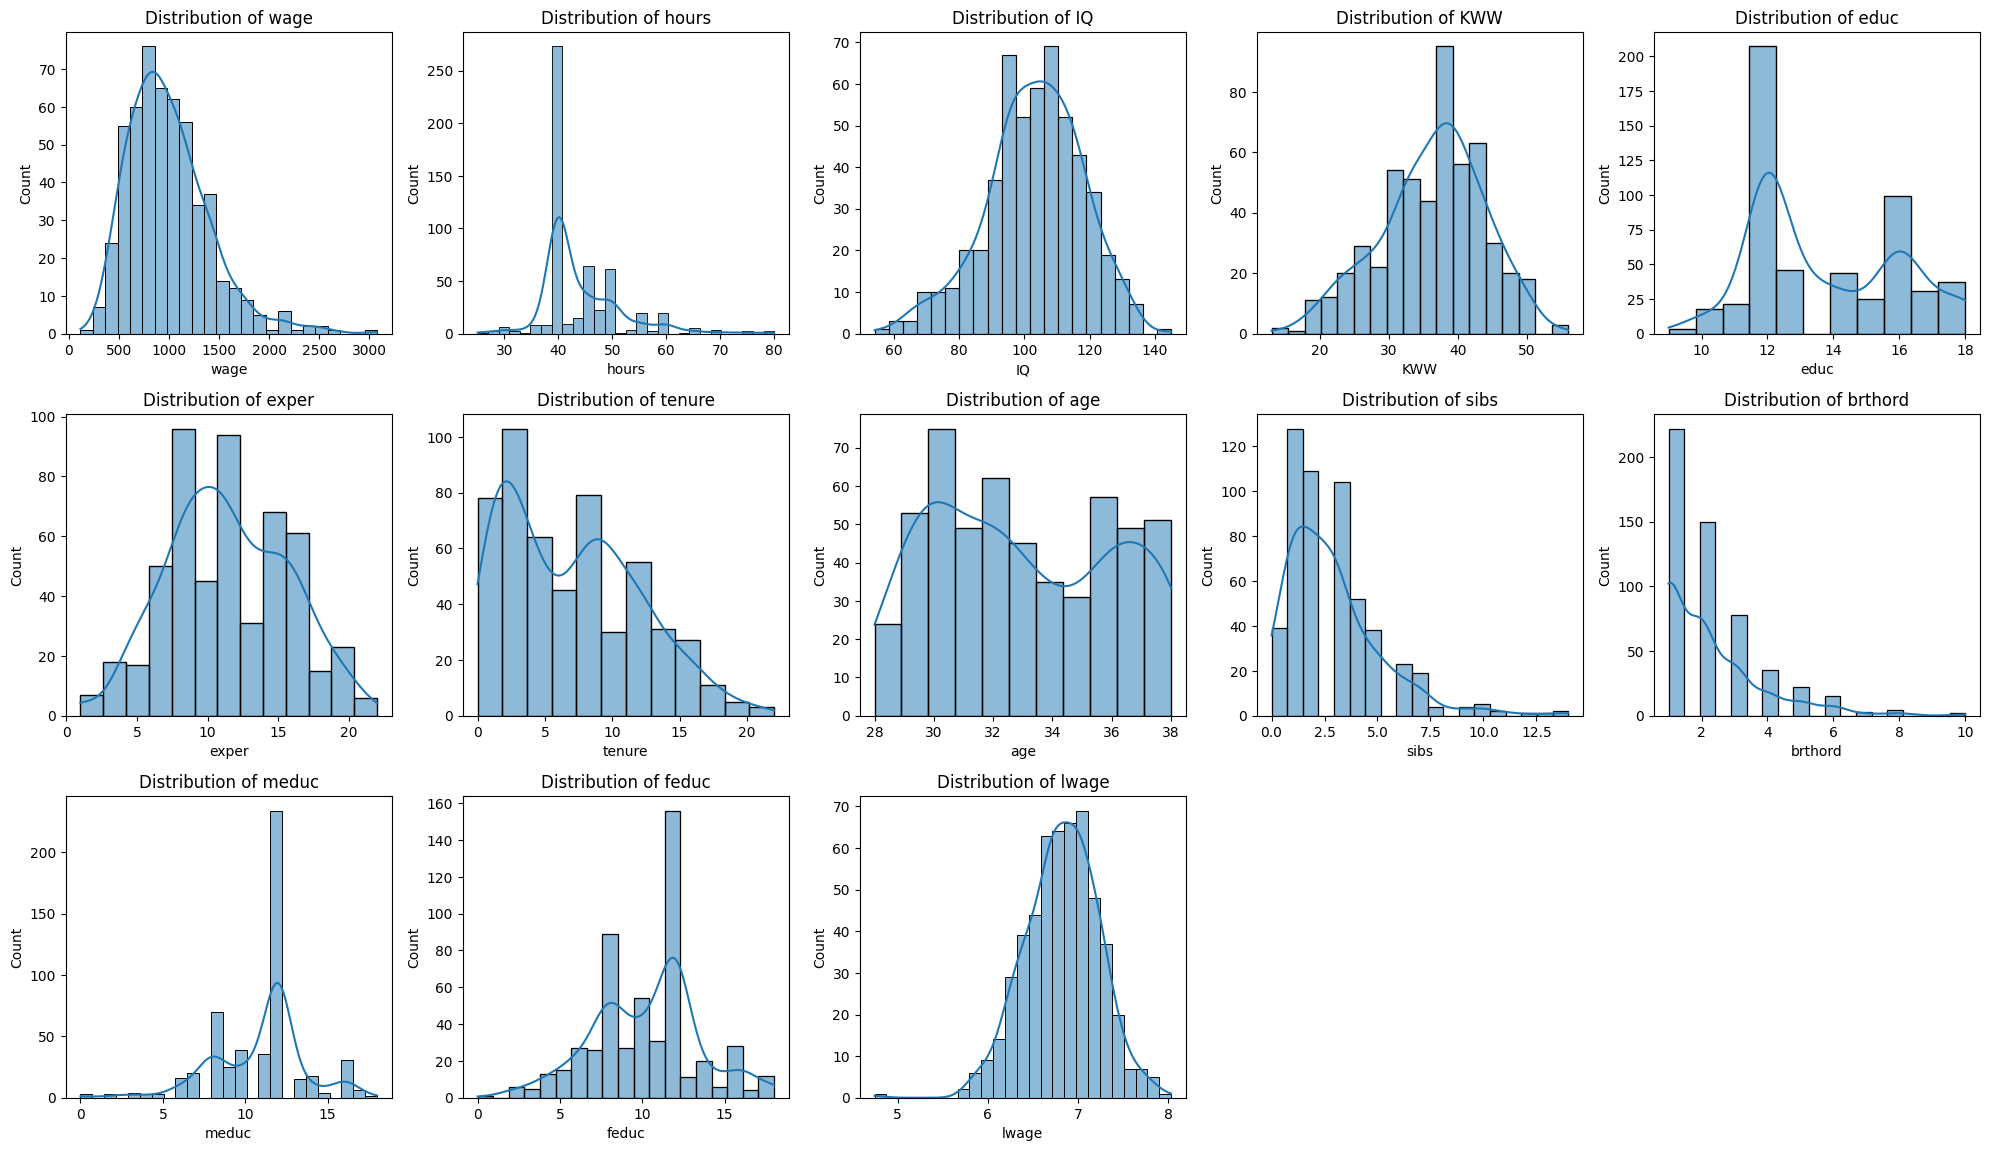

In [15]:
#Distribution of numerical variables
variables = ['wage','hours','IQ', 'KWW', 'educ', 'exper', 'tenure','age','sibs','brthord','meduc','feduc','lwage']
n_cols=5
n_rows=4
fig,axes=plt.subplots(n_rows,n_cols,figsize=(20,15))
axes=axes.flatten()
for i, var in enumerate(variables):
    sns.histplot(train[var],kde=True,ax=axes[i])
    axes[i].set_title(f'Distribution of {var}')
    axes[i].set_xlabel(var)
for j in range (i+1,len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

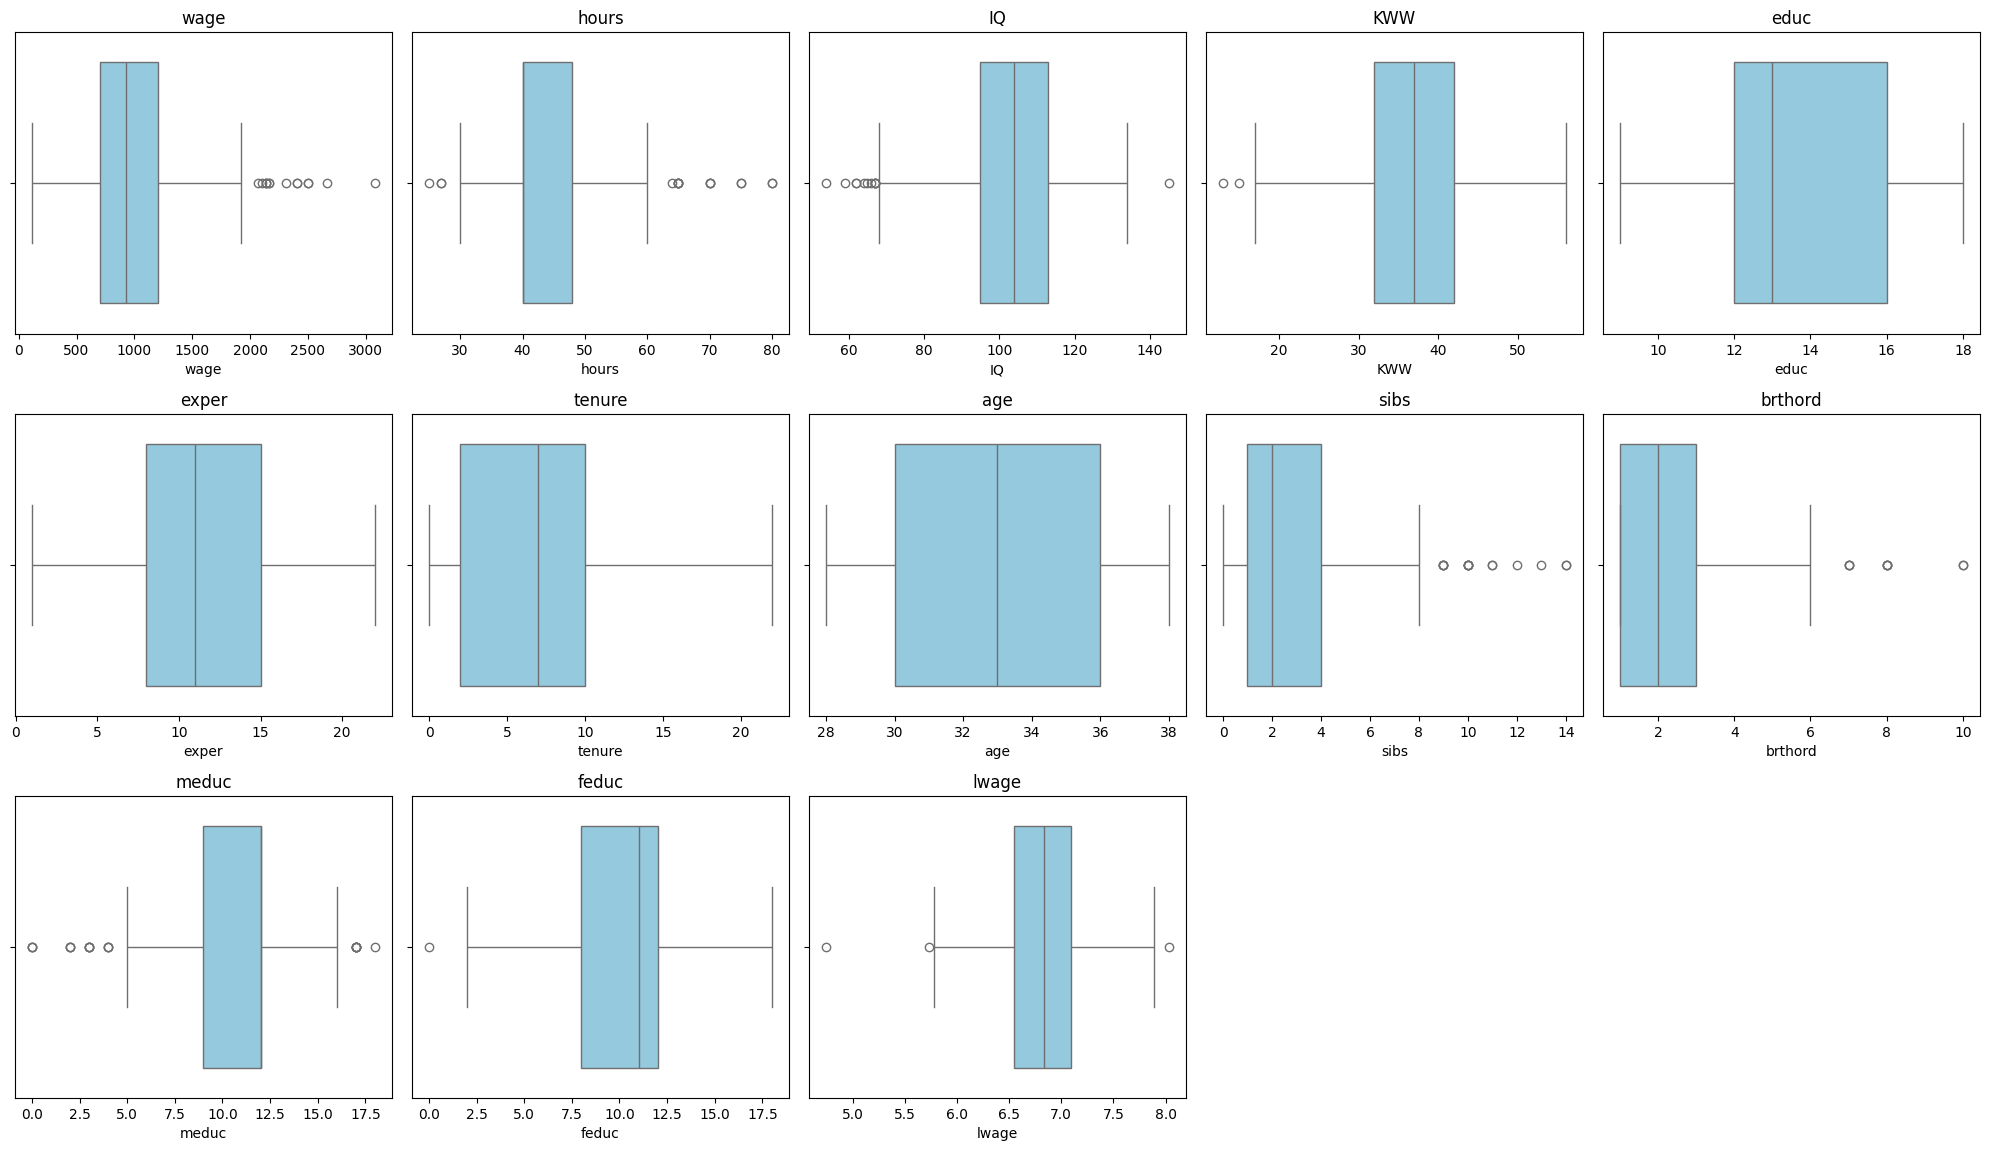

In [16]:
#boxplots of numerical variables
variables = ['wage','hours','IQ', 'KWW', 'educ', 'exper', 'tenure','age','sibs','brthord','meduc','feduc','lwage']
n_cols=5
n_rows=4
fig,axes=plt.subplots(n_rows,n_cols,figsize=(20,15))
axes=axes.flatten()
for i, var in enumerate(variables):
    sns.boxplot(x=train[var],ax=axes[i],color='skyblue')
    axes[i].set_title(f'{var}')
    axes[i].set_ylabel('')
for j in range (i+1,len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

The distribution of wage is skewed heavily to the right, indicating that most individuals earn around the lower range, and a few high-earners that push the tail.

In both sets of graphs, IQ, KWW, exper, educ, and lwage seem to be approximately normally distributed. This suggests that they could be used for future modelling stages, but assumptions remain unchecked and visual interpretation might not be completely correct. 

The variable lwage (log of wage) follows somewhat a normal distribution; therefore we can consider this for transformation effects in future stages. 

### **b. Distribution of categorical variables vs wage**

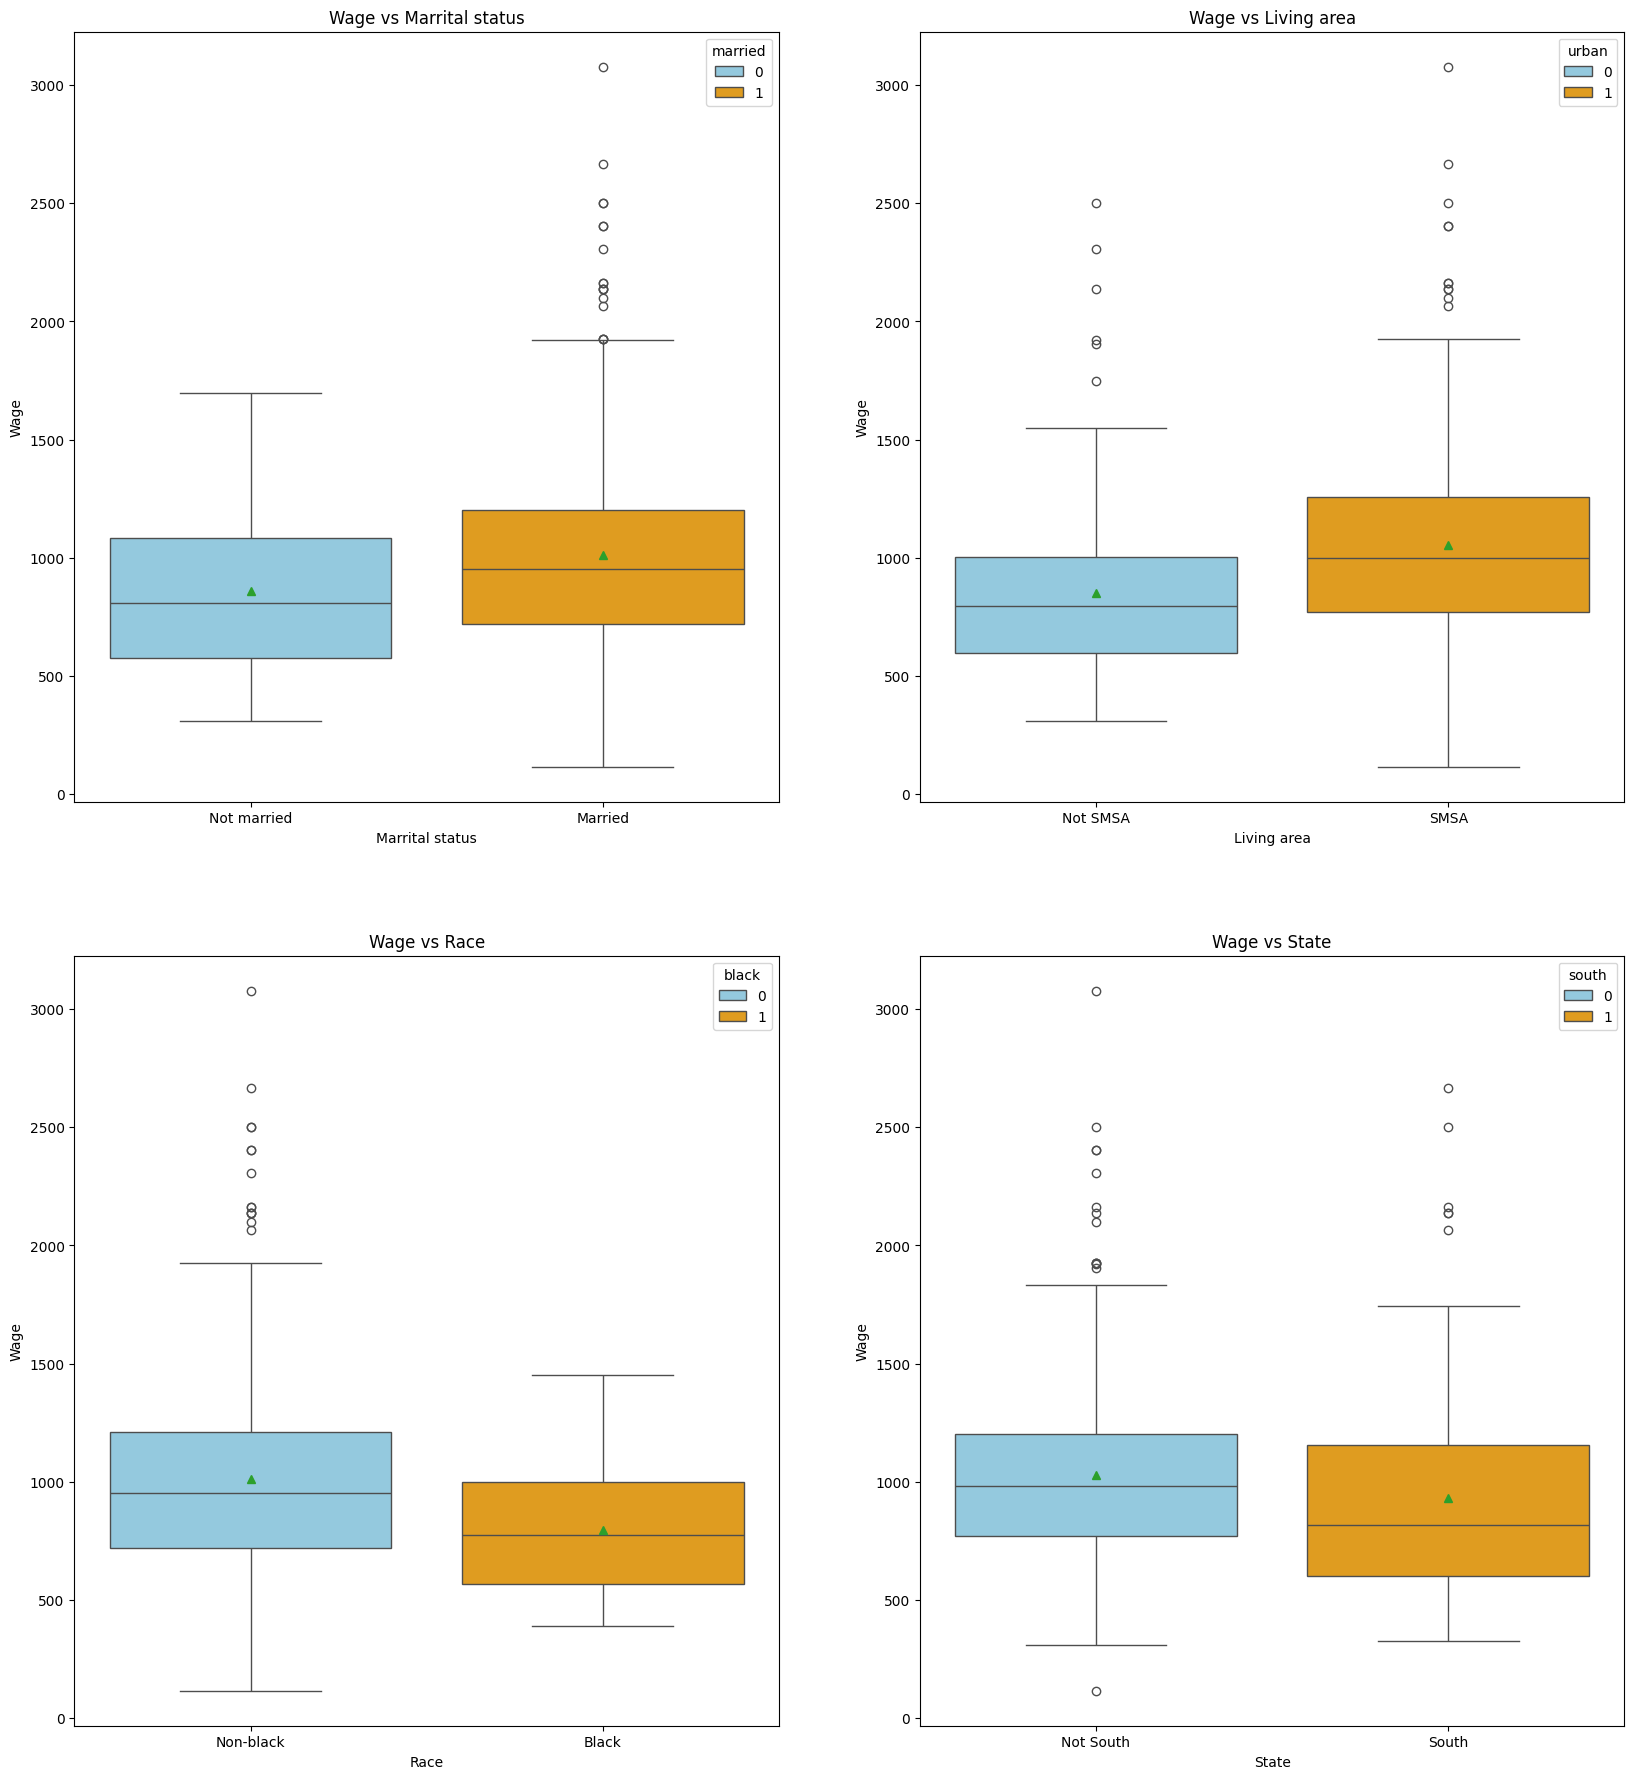

In [17]:
#side-by-side boxplots of wages vs categorical variabes
fig,ax=plt.subplots(2,2,figsize=(20,22))
sns.boxplot(x=train['married'],y=train['wage'],hue=train['married'],palette=['skyblue','orange'],ax=ax[0,0],showmeans=True)
ax[0,0].set_title('Wage vs Marrital status')
ax[0,0].set_xlabel('Marrital status')
ax[0,0].set_ylabel('Wage')
ax[0,0].set_xticks([0,1],['Not married','Married'])
sns.boxplot(x=train['urban'],y=train['wage'],hue=train['urban'],palette=['skyblue','orange'],ax=ax[0,1],showmeans=True)
ax[0,1].set_title('Wage vs Living area')
ax[0,1].set_xlabel('Living area')
ax[0,1].set_ylabel('Wage')
ax[0,1].set_xticks([0,1],['Not SMSA','SMSA'])
sns.boxplot(x=train['black'],y=train['wage'],hue=train['black'],palette=['skyblue','orange'],ax=ax[1,0],showmeans=True)
ax[1,0].set_title('Wage vs Race')
ax[1,0].set_xlabel('Race')
ax[1,0].set_ylabel('Wage')
ax[1,0].set_xticks([0,1],['Non-black','Black'])
sns.boxplot(x=train['south'],y=train['wage'],hue=train['south'],palette=['skyblue','orange'],ax=ax[1,1],showmeans=True)
ax[1,1].set_title('Wage vs State')
ax[1,1].set_xlabel('State')
ax[1,1].set_ylabel('Wage')
ax[1,1].set_xticks([0,1],['Not South','South'])
plt.show()

- Holding all else constant, married people have a higher median of wage than those who are not. Looking at the graph we can see that the box plot for married people have more outliers, which can cause skewness to higher values of wage. However, this distribution may suggest mild positive effects of marital status to monthly earnings. 

- Holding all else constant, people living in the SMSA have higher overall wages than those who are outside. the spread is also higher, indicating that people living in SMSA have higher wages overall. 

- Holding all else constant, black people have visibly lower wages than non-black people. They have lower median wage, as well as no outliers.

- Holding all else constant, people living in the South seem to have lower median wage than non-southern people, but overall not too much difference.

### **c. Correlation matrix of all variables**

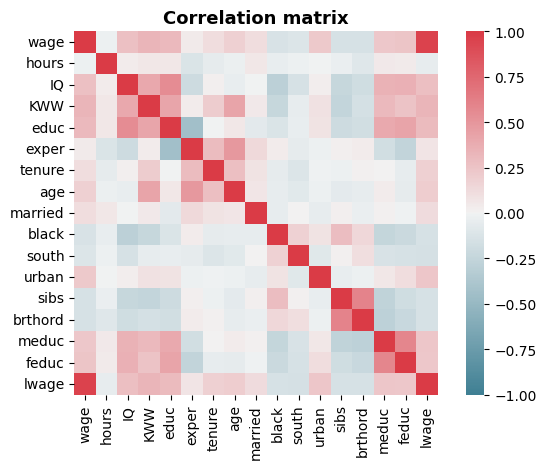

In [18]:
fig,ax=plt.subplots()
variables=['wage','hours','IQ', 'KWW', 'educ', 'exper', 'tenure','age','married','black','south','urban','sibs','brthord','meduc','feduc','lwage']
cmap = sns.diverging_palette(220, 10, as_cmap=True)
sns.heatmap(train[variables].corr(), vmax=1, vmin=-1, center=0, square=True, ax=ax, cmap=cmap)
ax.set_title('Correlation matrix', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

The correlation heat-map illustrates some strong positive and negative correlations between variables in this dataset. 
- Positive correlations with the response variable wage exist for IQ, KWW, educ, urban. Age, meduc, feduc, and urban also appear to be positively correlated with wage. The strongest positive correlation is with lwage, which is understandable as lwage is natural log of wage. 

- Surprisingly, exper (years of experience) seems to have little to none correlation with wage, while black and south are negatively correlated, aligning with the distribution graphs above.



In [19]:
train[variables].corr().round(2)

,wage,hours,IQ,KWW,educ,exper,tenure,age,married,black,south,urban,sibs,brthord,meduc,feduc,lwage
wage,1.00,-0.02,0.27,0.33,0.31,0.04,0.12,0.18,0.11,-0.14,-0.11,0.22,-0.15,-0.14,0.23,0.25,0.96
hours,-0.02,1.00,0.04,0.06,0.06,-0.12,-0.06,-0.03,0.06,-0.04,-0.02,-0.00,-0.03,-0.10,0.05,0.04,-0.05
IQ,0.27,0.04,1.00,0.40,0.55,-0.20,0.02,-0.04,-0.01,-0.29,-0.14,0.03,-0.24,-0.18,0.35,0.36,0.28
KWW,0.33,0.06,0.40,1.00,0.42,0.03,0.20,0.42,0.05,-0.24,-0.05,0.09,-0.25,-0.16,0.31,0.26,0.33
educ,0.31,0.06,0.55,0.42,1.00,-0.44,-0.00,0.05,-0.07,-0.12,-0.04,0.08,-0.20,-0.18,0.39,0.42,0.30
exper,0.04,-0.12,-0.20,0.03,-0.44,1.00,0.29,0.49,0.13,0.03,-0.06,-0.02,0.02,0.04,-0.18,-0.26,0.07
tenure,0.12,-0.06,0.02,0.20,-0.00,0.29,1.00,0.27,0.08,-0.06,-0.11,-0.01,-0.02,0.02,0.00,-0.05,0.18
age,0.18,-0.03,-0.04,0.42,0.05,0.49,0.27,1.00,0.07,-0.05,-0.08,-0.02,-0.07,-0.05,0.04,-0.06,0.20
married,0.11,0.06,-0.01,0.05,-0.07,0.13,0.08,0.07,1.00,-0.05,0.00,-0.05,0.02,-0.04,0.01,-0.01,0.12
black,-0.14,-0.04,-0.29,-0.24,-0.12,0.03,-0.06,-0.05,-0.05,1.00,0.18,0.08,0.28,0.15,-0.24,-0.21,-0.15


### **d. Scatter plots of all combinations of variables**

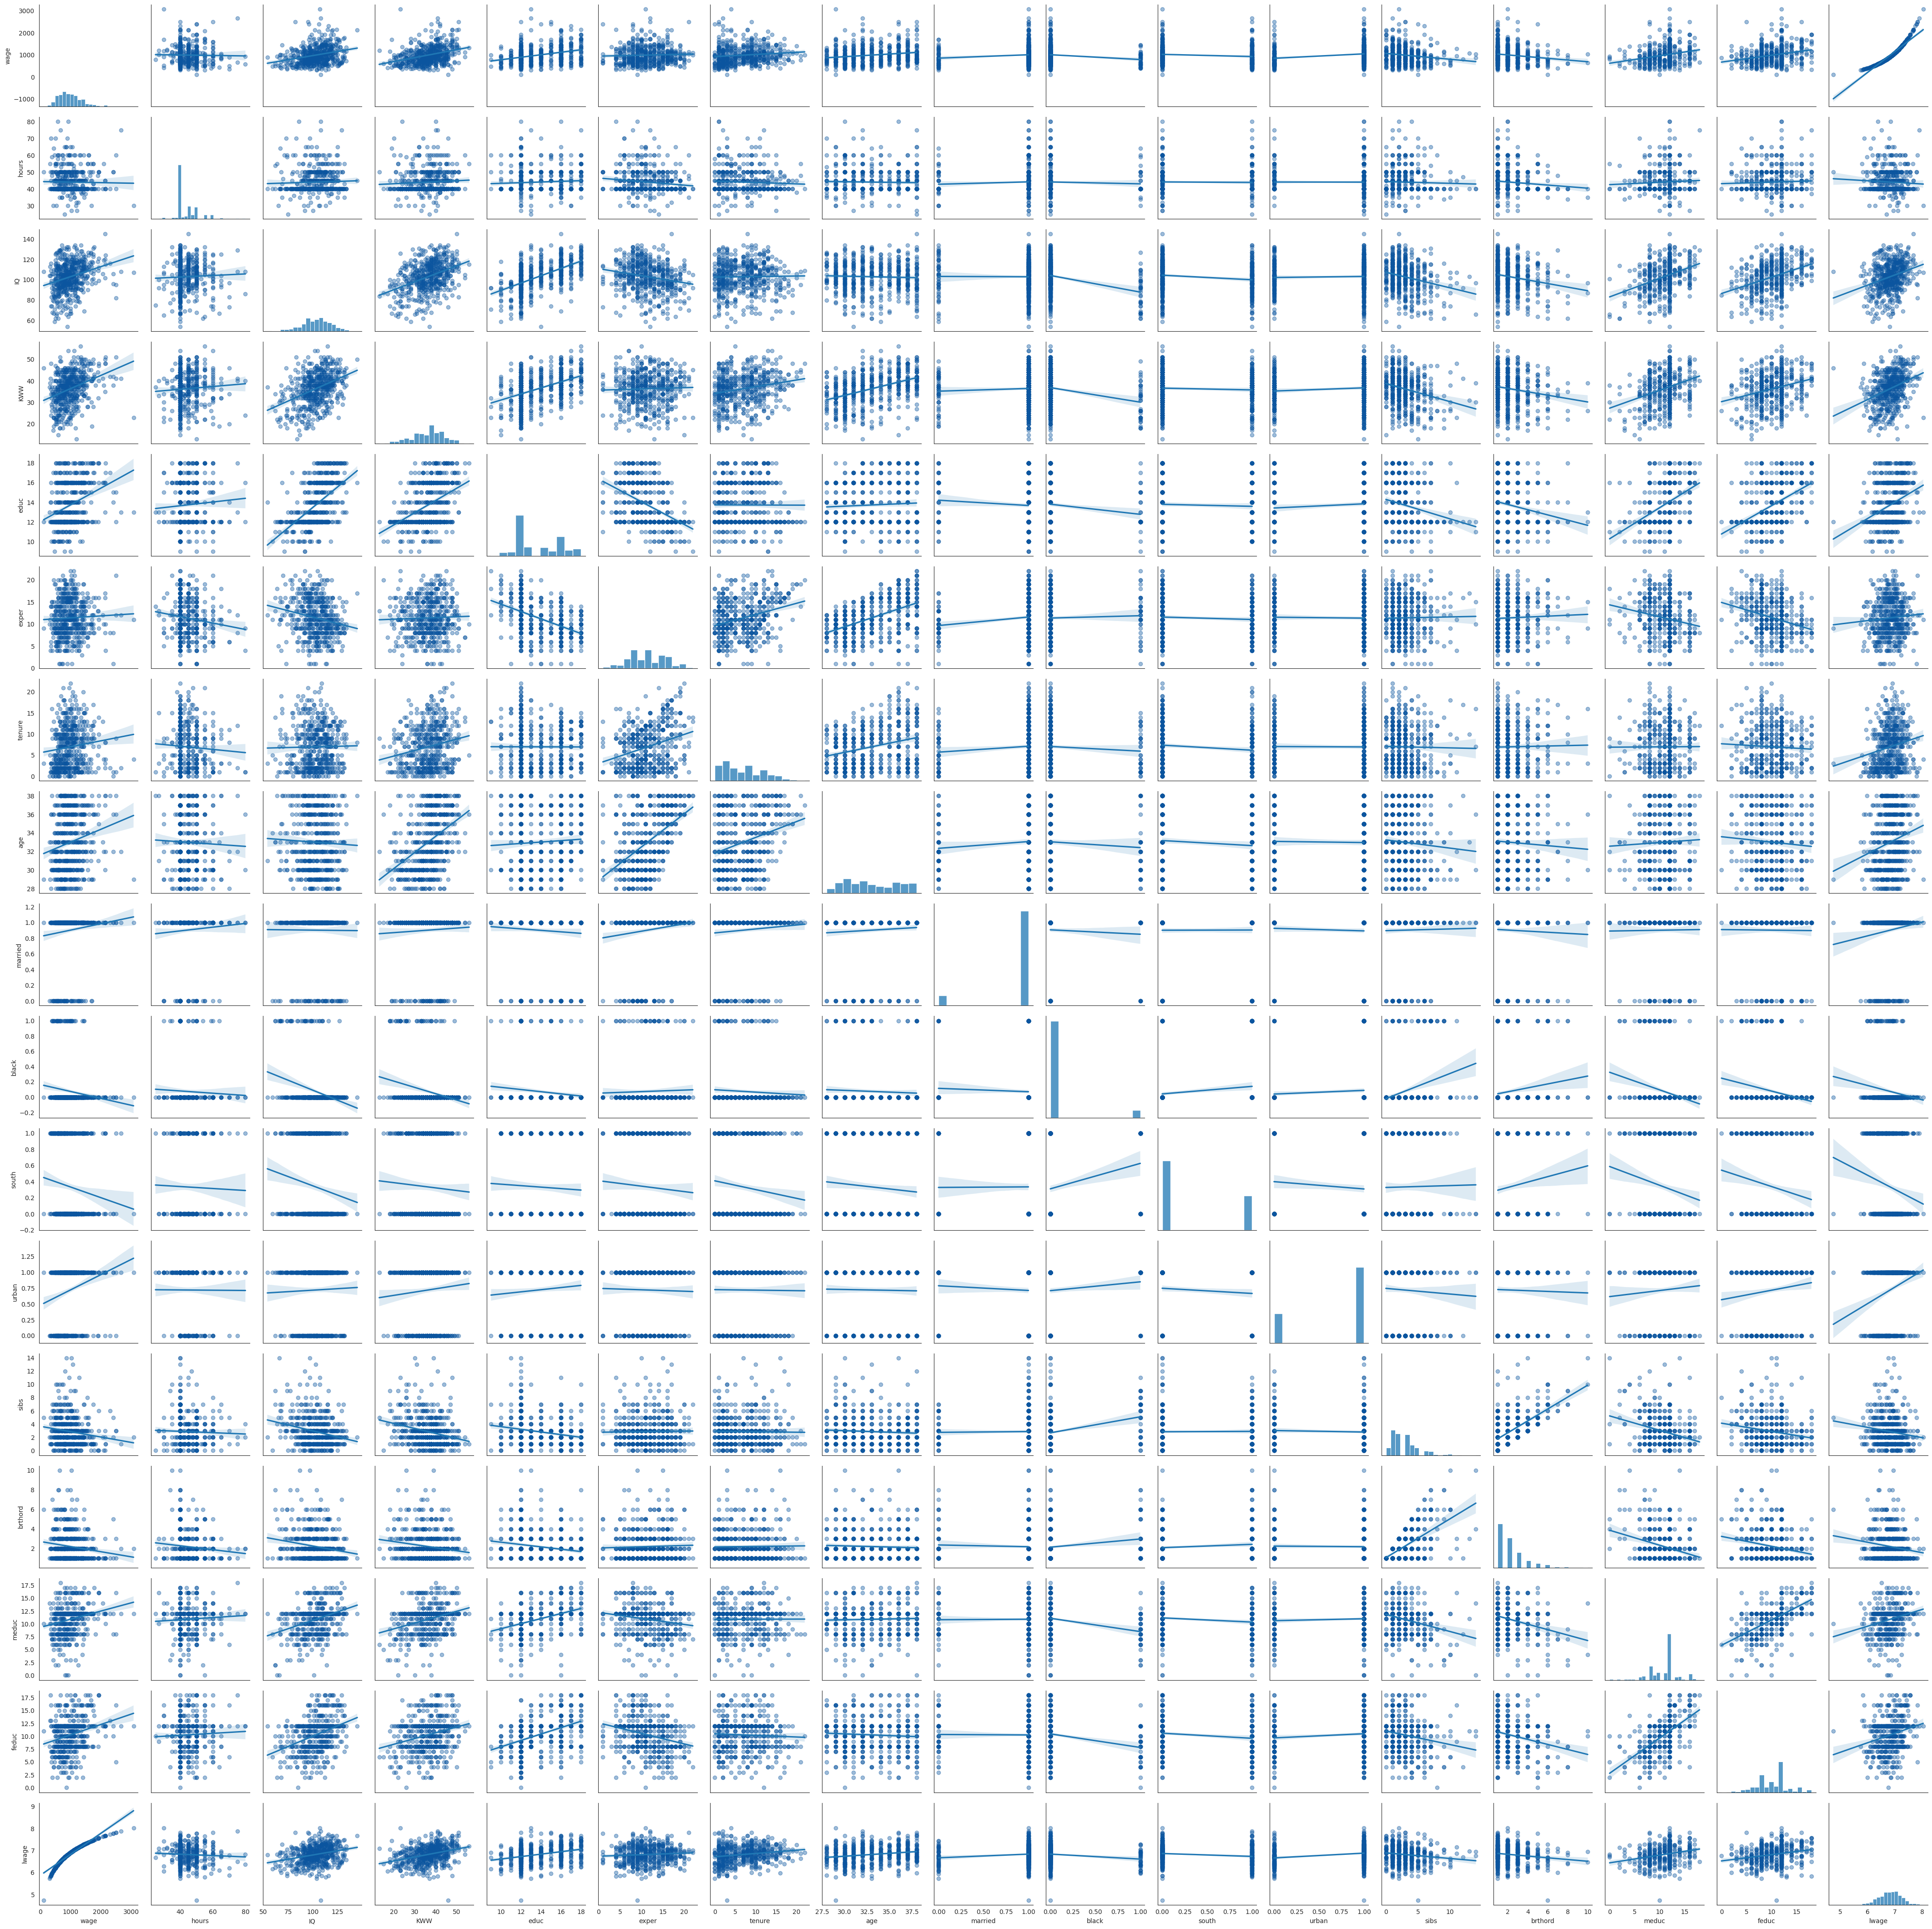

In [20]:
with sns.axes_style('white'):
    g=sns.pairplot(train[variables], kind='reg',
                   plot_kws={'scatter_kws' :{'color': sns.color_palette('Blues')[-1], 'alpha': 0.4}})
plt.tight_layout()
g.savefig('DM-pairplot.png', dpi=300)
plt.show()

Clear positive relationships exist between wage and variables such as IQ, KWW, and education. These relationships appear approximately linear and relatively strong, suggesting these variables may be important predictors in modeling wage. For example, as education increases, average wages also tend to rise, which aligns with economic expectations.

However, some relationships are more complex. The relationship between wage and experience (exper) is initially positive but flattens or even dips slightly at higher levels, indicating a potential non-linear trend. This is also reflected in the plot with tenure and age, where the pattern is less clearly linear and may warrant modeling with squared or interaction terms.

Several categorical variables such as married, black, south, and urban show distinct groupings in wage but with overlapping distributions, implying they may influence wage through interaction effects or differ in variance, rather than in pure mean differences.

Regarding the parental education variables (meduc and feduc), the relationships with wage are present but weak. This suggests background factors may have some influence, though they are not as predictive as an individual's own education or ability (as proxied by IQ and KWW).

In terms of relationships between the predictors, no extremely strong correlations are observed that would suggest problematic multicollinearity. While there are some moderate associations (e.g., between educ and IQ, or tenure and age), none are strong enough to cause immediate concern for variance inflation in the regression model. At this stage, multicollinearity does not appear to be a major issue.

# **Task 2: Analysis of relationship between exper, educ, and wage**

### **a. Data description**

In [21]:
train[['wage','educ','exper']].describe().round(2)  #training data description

,wage,educ,exper
count,531.00,531.00,531.00
mean,995.62,13.73,11.41
std,409.45,2.25,4.26
min,115.00,9.00,1.00
25%,700.00,12.00,8.00
50%,929.00,13.00,11.00
75%,1201.50,16.00,15.00
max,3078.00,18.00,22.00


### **b. Multiple Linear Regression (MLR)**

In [22]:
#Full model MLR (numerical + categorical)

model = smf.ols(formula='wage ~ hours +  IQ + KWW + educ + exper + tenure + age + married + black + south + urban + sibs + brthord + meduc + feduc', data=train)
reg = model.fit()
reg.summary() 

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   wage   R-squared:                       0.238
Model:                            OLS   Adj. R-squared:                  0.215
Method:                 Least Squares   F-statistic:                     10.70
Date:                Tue, 27 May 2025   Prob (F-statistic):           1.22e-22
Time:                        17:40:19   Log-Likelihood:                -3874.8
No. Observations:                 531   AIC:                             7782.
Df Residuals:                     515   BIC:                             7850.
Df Model:                          15                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   -594.3412    260.485     -2.282      0.023   -1106.085     -82.597
hours         -2.2238      2.215     -1.004      0.316      -6.576       2.128
IQ             1.9545      1.405      1.391      0.165      -0.807       4.716
KWW            6.6200      2.785      2.377      0.018       1.149      12.091
educ          37.9593     10.413      3.646      0.000      17.503      58.416
exper         12.1049      5.264      2.300      0.022       1.763      22.447
tenure         2.5618      3.434      0.746      0.456      -4.185       9.308
age            5.9827      6.944      0.862      0.389      -7.659      19.625
married      146.8417     54.020      2.718      0.007      40.716     252.968
black        -67.0372     66.932     -1.002      0.317    -198.531      64.457
south        -27.3144     35.273     -0.774      0.439     -96.611      41.982
urban        170.7131     36.030      4.738      0.000      99.929     241.497
sibs           1.5727      9.227      0.170      0.865     -16.555      19.700
brthord      -11.2680     13.480     -0.836      0.404     -37.750      15.214
meduc          3.2926      7.307      0.451      0.652     -11.062      17.648
feduc         11.1663      6.228      1.793      0.074      -1.070      23.402
==============================================================================
Omnibus:                      164.611   Durbin-Watson:                   1.823
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              630.335
Skew:                           1.378   Prob(JB):                    1.33e-137
Kurtosis:                       7.571   Cond. No.                     2.08e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.08e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

The effects of each variable can be summarized as:

Keeping all other variables constant, an increase of 1 average weekly hour is associated with an average decrease in the wage of 2.22 dollars.

Keeping all other variables constant, an increase of 1 IQ score is associated with an average increase in the wage of 1.95 dollars.

Keeping all other variables constant, an increase of 1 knowledge of world work score is associated with an average increase in the wage of 6.62 dollars.

Keeping all other variables constant, an increase of 1 year of education is associated with an average increase in the wage of 37.96 dollars.

Keeping all other variables constant, an increase of 1 year of experience is associated with an average increase in the wage of 12.10 dollars.

Keeping all other variables constant, an increase of 1 year with current employer is associated with an average decrease in the wage of 2.56 dollars.

Keeping all other variables constant, an increase of 1 age is associated with an average increase in the wage of 5.98 dollars.

Keeping all other variables constant, married people earns 146.84 dollars on average more than others. 

Keeping all other variables constant, black people earns 67.04 dollars on average less than others. 

Keeping all other variables constant, south people earns 27.31 dollars on average less than others. 

Keeping all other variables constant, urban people earns 170.71 dollars on average more than others. 

Keeping all other variables constant, an increase of 1 sibling is associated with an average increase in the wage of 1.57 dollars.

Keeping all other variables constant, an increase of 1 birth order is associated with an average decrease in the wage of 11.27 dollars.

Keeping all other variables constant, an increase of 1 year of mother's education is associated with an average increase in the wage of 3.29 dollars.

Keeping all other variables constant, an increase of 1 year of father's education is associated with an average increase in the wage of 11.17 dollars.


In [23]:
reg.mse_resid**0.5

np.float64(362.69230272797444)

In [24]:
#Full model MLR (numerical only)

model = smf.ols(formula='wage ~ hours +  IQ + KWW + educ + exper + tenure + age + sibs + brthord + meduc + feduc', data=train)
reg = model.fit()
reg.summary() 

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   wage   R-squared:                       0.192
Model:                            OLS   Adj. R-squared:                  0.175
Method:                 Least Squares   F-statistic:                     11.22
Date:                Tue, 27 May 2025   Prob (F-statistic):           8.69e-19
Time:                        17:40:19   Log-Likelihood:                -3890.2
No. Observations:                 531   AIC:                             7804.
Df Residuals:                     519   BIC:                             7856.
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   -433.6795    255.942     -1.694      0.091    -936.488      69.129
hours         -1.8101      2.265     -0.799      0.425      -6.260       2.640
IQ             2.0560      1.402      1.466      0.143      -0.699       4.811
KWW            8.0310      2.823      2.845      0.005       2.485      13.577
educ          37.5400     10.548      3.559      0.000      16.819      58.261
exper         14.3972      5.364      2.684      0.008       3.859      24.935
tenure         3.0966      3.498      0.885      0.376      -3.775       9.968
age            4.1275      7.083      0.583      0.560      -9.787      18.042
sibs           0.6802      9.176      0.074      0.941     -17.347      18.708
brthord      -12.2056     13.679     -0.892      0.373     -39.079      14.668
meduc          4.0213      7.455      0.539      0.590     -10.625      18.668
feduc         14.5355      6.332      2.295      0.022       2.095      26.976
==============================================================================
Omnibus:                      151.318   Durbin-Watson:                   1.804
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              526.871
Skew:                           1.294   Prob(JB):                    3.90e-115
Kurtosis:                       7.138   Cond. No.                     1.99e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.99e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [25]:
#Reduced model (educ + exper)

model_base = smf.ols(formula='wage ~ educ + exper', data=train) 
regbase = model_base.fit()
regbase.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   wage   R-squared:                       0.136
Model:                            OLS   Adj. R-squared:                  0.132
Method:                 Least Squares   F-statistic:                     41.43
Date:                Tue, 27 May 2025   Prob (F-statistic):           1.93e-17
Time:                        17:40:20   Log-Likelihood:                -3908.1
No. Observations:                 531   AIC:                             7822.
Df Residuals:                     528   BIC:                             7835.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   -264.3942    142.291     -1.858      0.064    -543.921      15.133
educ          74.1534      8.201      9.042      0.000      58.043      90.263
exper         21.2275      4.323      4.910      0.000      12.735      29.720
==============================================================================
Omnibus:                      135.138   Durbin-Watson:                   1.867
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              389.743
Skew:                           1.220   Prob(JB):                     2.34e-85
Kurtosis:                       6.416   Cond. No.                         155.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

Similar to the full model, both variables educ and exper are positively related to wage. The effects of each variable can be summarized as:

- Keeping years of work experience constant, an increase of 1 year of education is associated with an average increase in the wage of 74.15 dollars.
- Keeping years of education constant, an increase of 1 year of experience is associated with an average increase in the wage of 21.23 dollars.

Noteworthily, the estimated coefficients for educ and exper in the reduced model are significantly different to their respective etimates in the full model (nearly twice the full model's estimation). This could be evidence of some omitted variable bias (OVB) in this reduced model, for both variables. We consider this in more detail in Task 3. 


In [26]:
residbase=regbase.resid
fitbase=regbase.fittedvalues
regbase.mse_resid**0.5

np.float64(381.38333895467906)

In [27]:
train[['educ','exper']].corr()

,educ,exper
educ,1.000000,-0.438547
exper,-0.438547,1.000000


In [28]:
1/(1-(-0.438547**2))

0.8386985781517942

### **c. Measure of fit (reduced model)**

- The full model has $R^2$ = 0.238$, $R^2_{adj}$ = 0.215$ and SER = $362.69$ dollars. This means that it captures about $19\%$ of the variation in wages, with a typical prediction error of about $\$363$.
- The reduced model has $R^2 = 0.136$, $R^2_{adj} = 0.132$ and SER = $375.64$ dollars. This means that it captures about $14\%$ of the variation in wages, with a typical prediction error of about $\$376$. 

Both models are relatively weak fits to the data, but the full model is the strongest fit between the two, capturing about $10$ percentage point more variation in wages and reducing the prediction error by about $\$13$.   

The low values for $R^2$ and $R^2_{adj}$ can mainly be due to weak predictors overall of the model (intuitively sibs, brthord, etc. may have have little real impact on wage) and non-linearity of some of the variables. Therefore, other meaningful predictors should rather be used, and transformations will be further examined in Task 3 and 4. Another concern is with the amount of data we have dropped in the data cleaning process: up to 1/3 of original data. This may cause significant reduction in $R^2$ and $R^2{adj}$. 

The variance inflation can be measured by the $R^2$ in the regression of one regressor on the other. Both equal to $\frac{1}{1-r^2}$, where $r$ is the correlation between educ and exper, as calculated above, equal 0.84. This is not a large number -- the usual threshold for the presence of a multicollinearity problem is 5.


In [29]:
#calculate VIFs for predictors
features=train[['educ','exper']]
features=sm.add_constant(features)
from statsmodels.stats.outliers_influence import variance_inflation_factor
vif=[]
for i in range(1,features.shape[1]):
    vif_value=variance_inflation_factor(features.values,i)
    vif.append(vif_value)
    print(f"VIF for {features.columns[i]}: {vif_value:.3f}")
average_vif=sum(vif)/len(vif)
print(f"Average VIF: {average_vif:.3f}")

VIF for educ: 1.238
VIF for exper: 1.238
Average VIF: 1.238


The VIF for educ and exper are 1.238 each, which is well below the common thresholds of 5 or 10. This means that no significant multicollinearity is happnening between educ and exper, making the data much more meaningful.

### **d. Assessment of reduced model's goodness of fit**

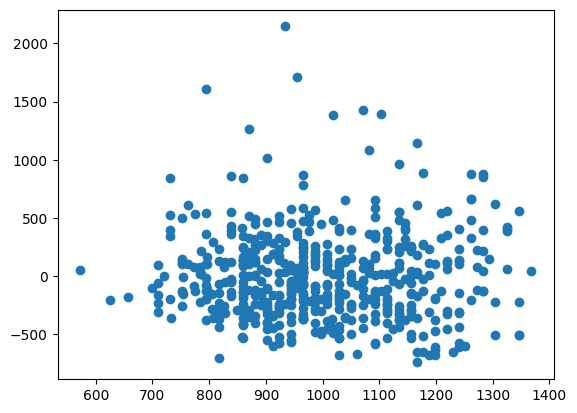

In [30]:
plt.scatter(fitbase,residbase)
plt.show()

/opt/anaconda3/envs/skywalker/lib/python3.13/site-packages/statsmodels/nonparametric/smoothers_lowess.py:226: RuntimeWarning: invalid value encountered in divide
  res, _ = _lowess(y, x, x, np.ones_like(x),


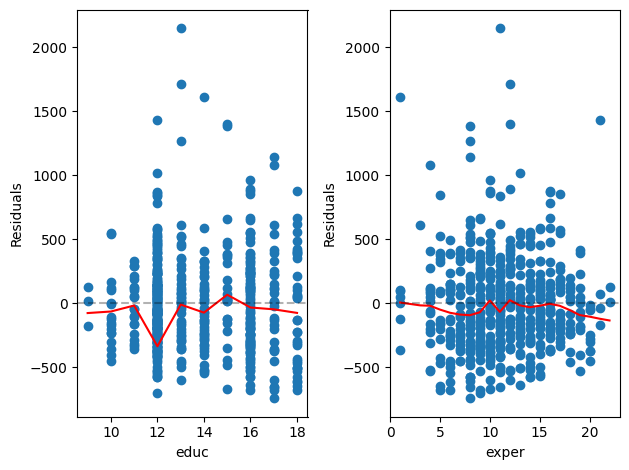

In [31]:

lowess = sm.nonparametric.lowess

fig = plt.figure()
ax1 = fig.add_subplot(1, 2, 1)
ax2 = fig.add_subplot(1, 2, 2)

# First plot (educ vs residuals)
mask1 = (
    ~regbase.resid.isna() & 
    ~train['educ'].isna() & 
    np.isfinite(regbase.resid) & 
    np.isfinite(train['educ'])
)
ax1.scatter(train['educ'], regbase.resid)
z1 = lowess(regbase.resid[mask1], train['educ'][mask1], frac=1./5)
ax1.plot(z1[:, 0], z1[:, 1], 'red')
ax1.set_xlabel('educ')
ax1.set_ylabel('Residuals')
ax1.axhline(color='Black', alpha=0.3, linestyle='--')

# Second plot (exper vs residuals)
mask2 = (
    ~regbase.resid.isna() & 
    ~train['exper'].isna() & 
    np.isfinite(regbase.resid) & 
    np.isfinite(train['exper'])
)
ax2.scatter(train['exper'], regbase.resid)
z2 = lowess(regbase.resid[mask2], train['exper'][mask2], frac=1./5)
ax2.plot(z2[:, 0], z2[:, 1], 'red')
ax2.set_xlabel('exper')
ax2.set_ylabel('Residuals')
ax2.axhline(color='Black', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

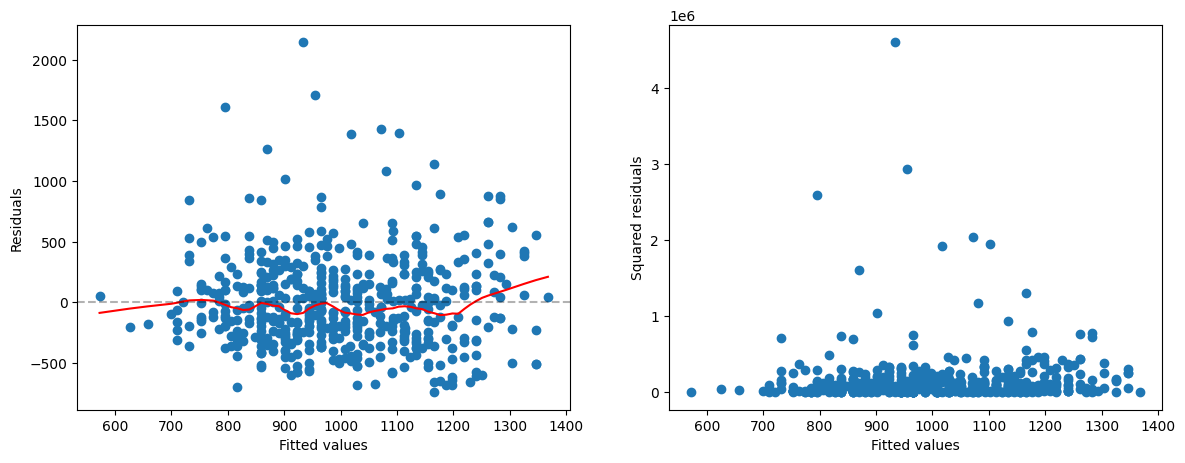

In [32]:
#Residual and squared residual plots against fitted values
fig = plt.figure(figsize=(14,5))
ax1=fig.add_subplot(1,2,1)
ax2=fig.add_subplot(1,2,2)
ax1.scatter(regbase.fittedvalues,regbase.resid)
z1=lowess(regbase.resid,regbase.fittedvalues,frac=1./5)
ax1.plot(z1[:,0],z1[:,1],'red')
ax1.set_xlabel('Fitted values')
ax1.set_ylabel('Residuals')
ax1.axhline(color='Black',alpha=0.3,linestyle='--')
residbase2=regbase.resid**2
ax2.scatter(regbase.fittedvalues,residbase2)
ax2.set_xlabel('Fitted values')
ax2.set_ylabel('Squared residuals')
plt.show()

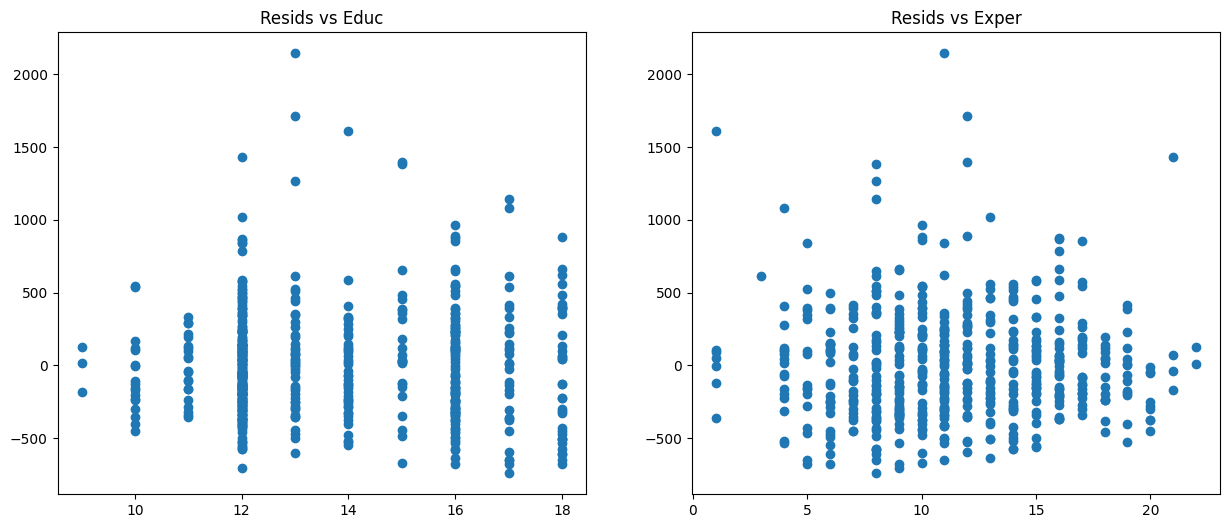

In [33]:
fig = plt.figure(figsize=(15,6))
ax1 = fig.add_subplot(1,2,1)
ax2 = fig.add_subplot(1,2,2)
ax1.scatter(train['educ'],residbase)
ax1.set_title("Resids vs Educ")
ax2.scatter(train['exper'], residbase)
ax2.set_title("Resids vs Exper")
plt.show()

The residuals vs fitted values plot shows no clear pattern in the mean, i.e. the errors seem to average close to 0 for most fitted values, as confirmed by the LOESS curve (apart from a mild dip in the middle). The residuals vs each predictor show that **E**$(e|X) = 0$ appears to hold for most value of $X$. Thus, the linear model seems a reasonable fit for the wage data.

However, there is evidence that the variance of residuals increases slightly for higher fitted values. This is visible in the squared residuals plot, where spread is larger at the extremes. Hence, the assumption of constant variance may not hold, and inference may benefit from using heteroskedasticity-robust standard errors.

The scatter plots of wage against each predictor (in blue), overlaid with fitted values (in red), offer additional insights:

For **education**, the red predicted values track the increasing trend in wage with rising education, though they tend to underpredict for higher earners.

For **experience**, a similar pattern is observed: predictions follow the general shape of the data but fail to capture some curvature or variance at higher experience levels. These plots suggest that the model captures the main linear trend well, though it might benefit from polynomial or interaction terms for more accuracy. 

Regarding the other MLR LSA:

**LSA 2** requires **E**$(e|X) = 0$. While the residual plots support this assumption, it may still be violated due to **omitted variable bias**. For instance, IQ and KWW, which show a positive correlation with wage and likely correlate with educ, are not included in this model. This may bias the coefficient estimates for educ.

**LSA 3** assumes that the observations are i.i.d. As we lack temporal or cluster structure in the data, we proceed under this assumption.

**LSA 4** concerns finite $4^{th}$ moments. Variables such as exper, educ and wage are bounded in practice and show no severe outliers, so this assumption is reasonably satisfied. 

**LSA 5** (no perfect multicollinearity): educ and exper and only moderately correlated (~ -0.44), which is well below the threshold for concern. We tested this again using VIF, and the result cemented the previous argument. Hence, no standout multicollinearity issues are detected. 

### **e. Interaction effect between educ and exper**

In [34]:
task2interact = smf.ols('wage ~ educ + exper + educ:exper', data = train).fit()
print(task2interact.summary())

                            OLS Regression Results                            
Dep. Variable:                   wage   R-squared:                       0.147
Model:                            OLS   Adj. R-squared:                  0.142
Method:                 Least Squares   F-statistic:                     30.24
Date:                Tue, 27 May 2025   Prob (F-statistic):           4.76e-18
Time:                        17:40:20   Log-Likelihood:                -3904.7
No. Observations:                 531   AIC:                             7817.
Df Residuals:                     527   BIC:                             7834.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    494.5601    321.511      1.538      0.1

Compared to the reduced model (consisting of educ and exper only), this model that includes the interaction effect produced a higher $R^2$ and $R^2_{adj}$. The model without interaction effect has adjusted $R^2$ of 0.132 while that of the new model is 0.142, slightly better. 

Notably, the p-value for the interaction effect between educ and exper here is statistically significant with 0.009 < 0.05 (chosen alpha), allowing us to reject the hypothesis that the interaction between these 2 variables has no effect on wage. 

This suggests that the effect of education on wage depends on the level of education, and vice versa.

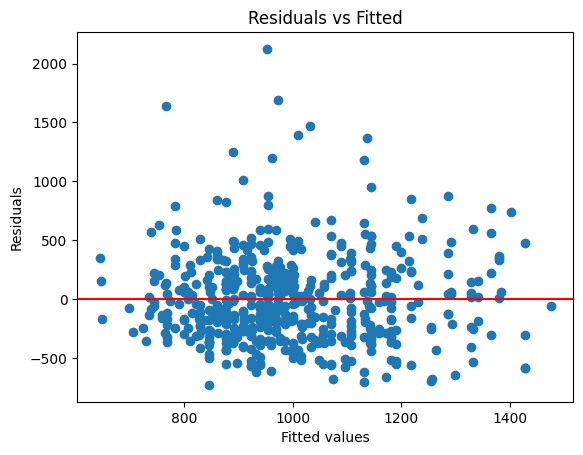

In [35]:
fitted_vals = task2interact.fittedvalues
residuals = task2interact.resid

plt.scatter(fitted_vals, residuals)
plt.axhline(y=0, color='red')
plt.xlabel('Fitted values')
plt.ylabel('Residuals')
plt.title('Residuals vs Fitted')
plt.show()

The residuals vs. fitted values plot shows no visible signs of heteroskedasticity; therefore, we can assume LSA 6 (homoskedasticity) holds in this model.

# **Task 3: Omitted Variable Bias**

### **a. Discussion of possible variables that can cause OVB**

### Reduced model with educ and exper

In [36]:

model_base = smf.ols(formula='wage ~ educ + exper', data=train) 
regbase = model_base.fit()
regbase.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   wage   R-squared:                       0.136
Model:                            OLS   Adj. R-squared:                  0.132
Method:                 Least Squares   F-statistic:                     41.43
Date:                Tue, 27 May 2025   Prob (F-statistic):           1.93e-17
Time:                        17:40:20   Log-Likelihood:                -3908.1
No. Observations:                 531   AIC:                             7822.
Df Residuals:                     528   BIC:                             7835.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   -264.3942    142.291     -1.858      0.064    -543.921      15.133
educ          74.1534      8.201      9.042      0.000      58.043      90.263
exper         21.2275      4.323      4.910      0.000      12.735      29.720
==============================================================================
Omnibus:                      135.138   Durbin-Watson:                   1.867
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              389.743
Skew:                           1.220   Prob(JB):                     2.34e-85
Kurtosis:                       6.416   Cond. No.                         155.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

### Discussion of possible OVB causes

The variable KWW appears to be the most likely determinant of an individual's wage since it has the highest positive correlation with wage out of all other variables ($r = 0.42$). KWW is also intuitively logical as individuals with higher levels of education are likely to score higher on knowledge-based assessments. 

IQ also seems like a reasonable choice, as it may be related to years of education and work experience. It is also positively correlated with wage and educ ($r$ = $0.27$ and $0.55$ respectively) while negatively related to years of experience with correlation of -$0.20$.

Age, meduc, and feduc are also considerably positively correlated with wage, educ, and exper. And these all are logically correlated with all 3 base variables through time of life and choices of parents. 

Looking at the full model, the urban variable also shows a p-value of $0.000$ < $0.05$ (chosen alpha), making it a good choice for testing OVB. Intuitively, people who live in urban areas are also introduced to more opportunities. 

Tenure (years with current employees), however, may seem like a good cause for OVB but is also likely to cause multicollinearity as it is too similar to exper. We will discuss this later.

In summary, this report will include IQ, KWW, age, urban, meduc, and feduc to check for omitted variable bias. 

In [37]:
newmodel = smf.ols(formula='wage ~ educ + exper + IQ + KWW + age + urban + meduc + feduc', data=train)
newreg = newmodel.fit()
newreg.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   wage   R-squared:                       0.220
Model:                            OLS   Adj. R-squared:                  0.208
Method:                 Least Squares   F-statistic:                     18.38
Date:                Tue, 27 May 2025   Prob (F-statistic):           2.50e-24
Time:                        17:40:20   Log-Likelihood:                -3880.9
No. Observations:                 531   AIC:                             7780.
Df Residuals:                     522   BIC:                             7818.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   -716.1607    219.850     -3.258      0.001   -1148.059    -284.262
educ          35.8821     10.326      3.475      0.001      15.596      56.169
exper         14.9024      5.106      2.919      0.004       4.871      24.934
IQ             2.4747      1.371      1.805      0.072      -0.219       5.169
KWW            7.2720      2.723      2.671      0.008       1.923      12.621
age            6.6866      6.941      0.963      0.336      -6.949      20.322
urban        163.4080     35.693      4.578      0.000      93.288     233.528
meduc          5.6974      7.181      0.793      0.428      -8.410      19.805
feduc         12.6092      6.205      2.032      0.043       0.420      24.799
==============================================================================
Omnibus:                      153.505   Durbin-Watson:                   1.787
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              561.625
Skew:                           1.295   Prob(JB):                    1.11e-122
Kurtosis:                       7.322   Cond. No.                     1.63e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.63e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

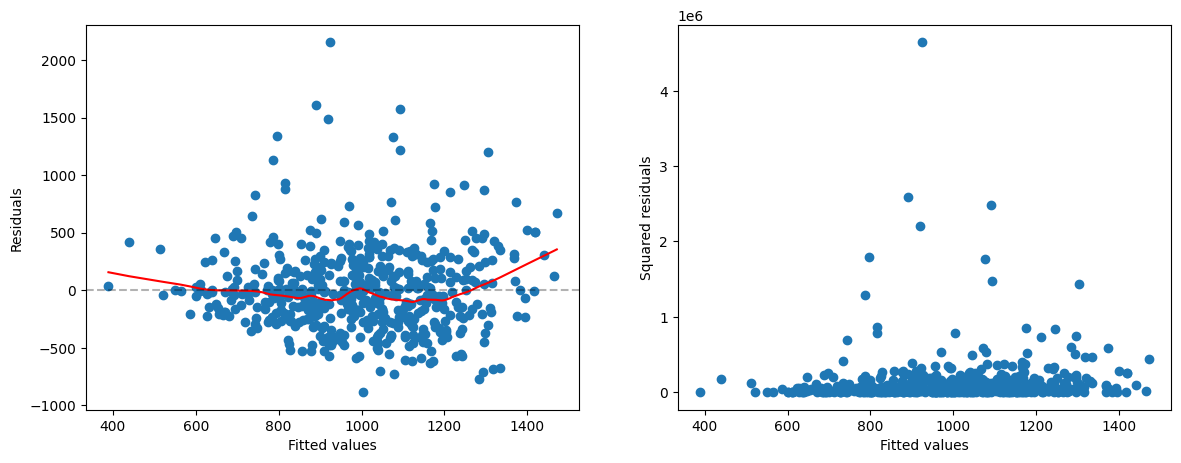

In [38]:
#Residual and squared residual plots against fitted values
fig = plt.figure(figsize=(14,5))
ax1=fig.add_subplot(1,2,1)
ax2=fig.add_subplot(1,2,2)
ax1.scatter(newreg.fittedvalues,newreg.resid)
z1=lowess(newreg.resid,newreg.fittedvalues,frac=1./5)
ax1.plot(z1[:,0],z1[:,1],'red')
ax1.set_xlabel('Fitted values')
ax1.set_ylabel('Residuals')
ax1.axhline(color='Black',alpha=0.3,linestyle='--')
newreg2=newreg.resid**2
ax2.scatter(newreg.fittedvalues,newreg2)
ax2.set_xlabel('Fitted values')
ax2.set_ylabel('Squared residuals')
plt.show()

In [39]:
newresid=newreg.resid
newfit=newreg.fittedvalues
newreg.mse_resid**0.5

np.float64(364.43264904928503)

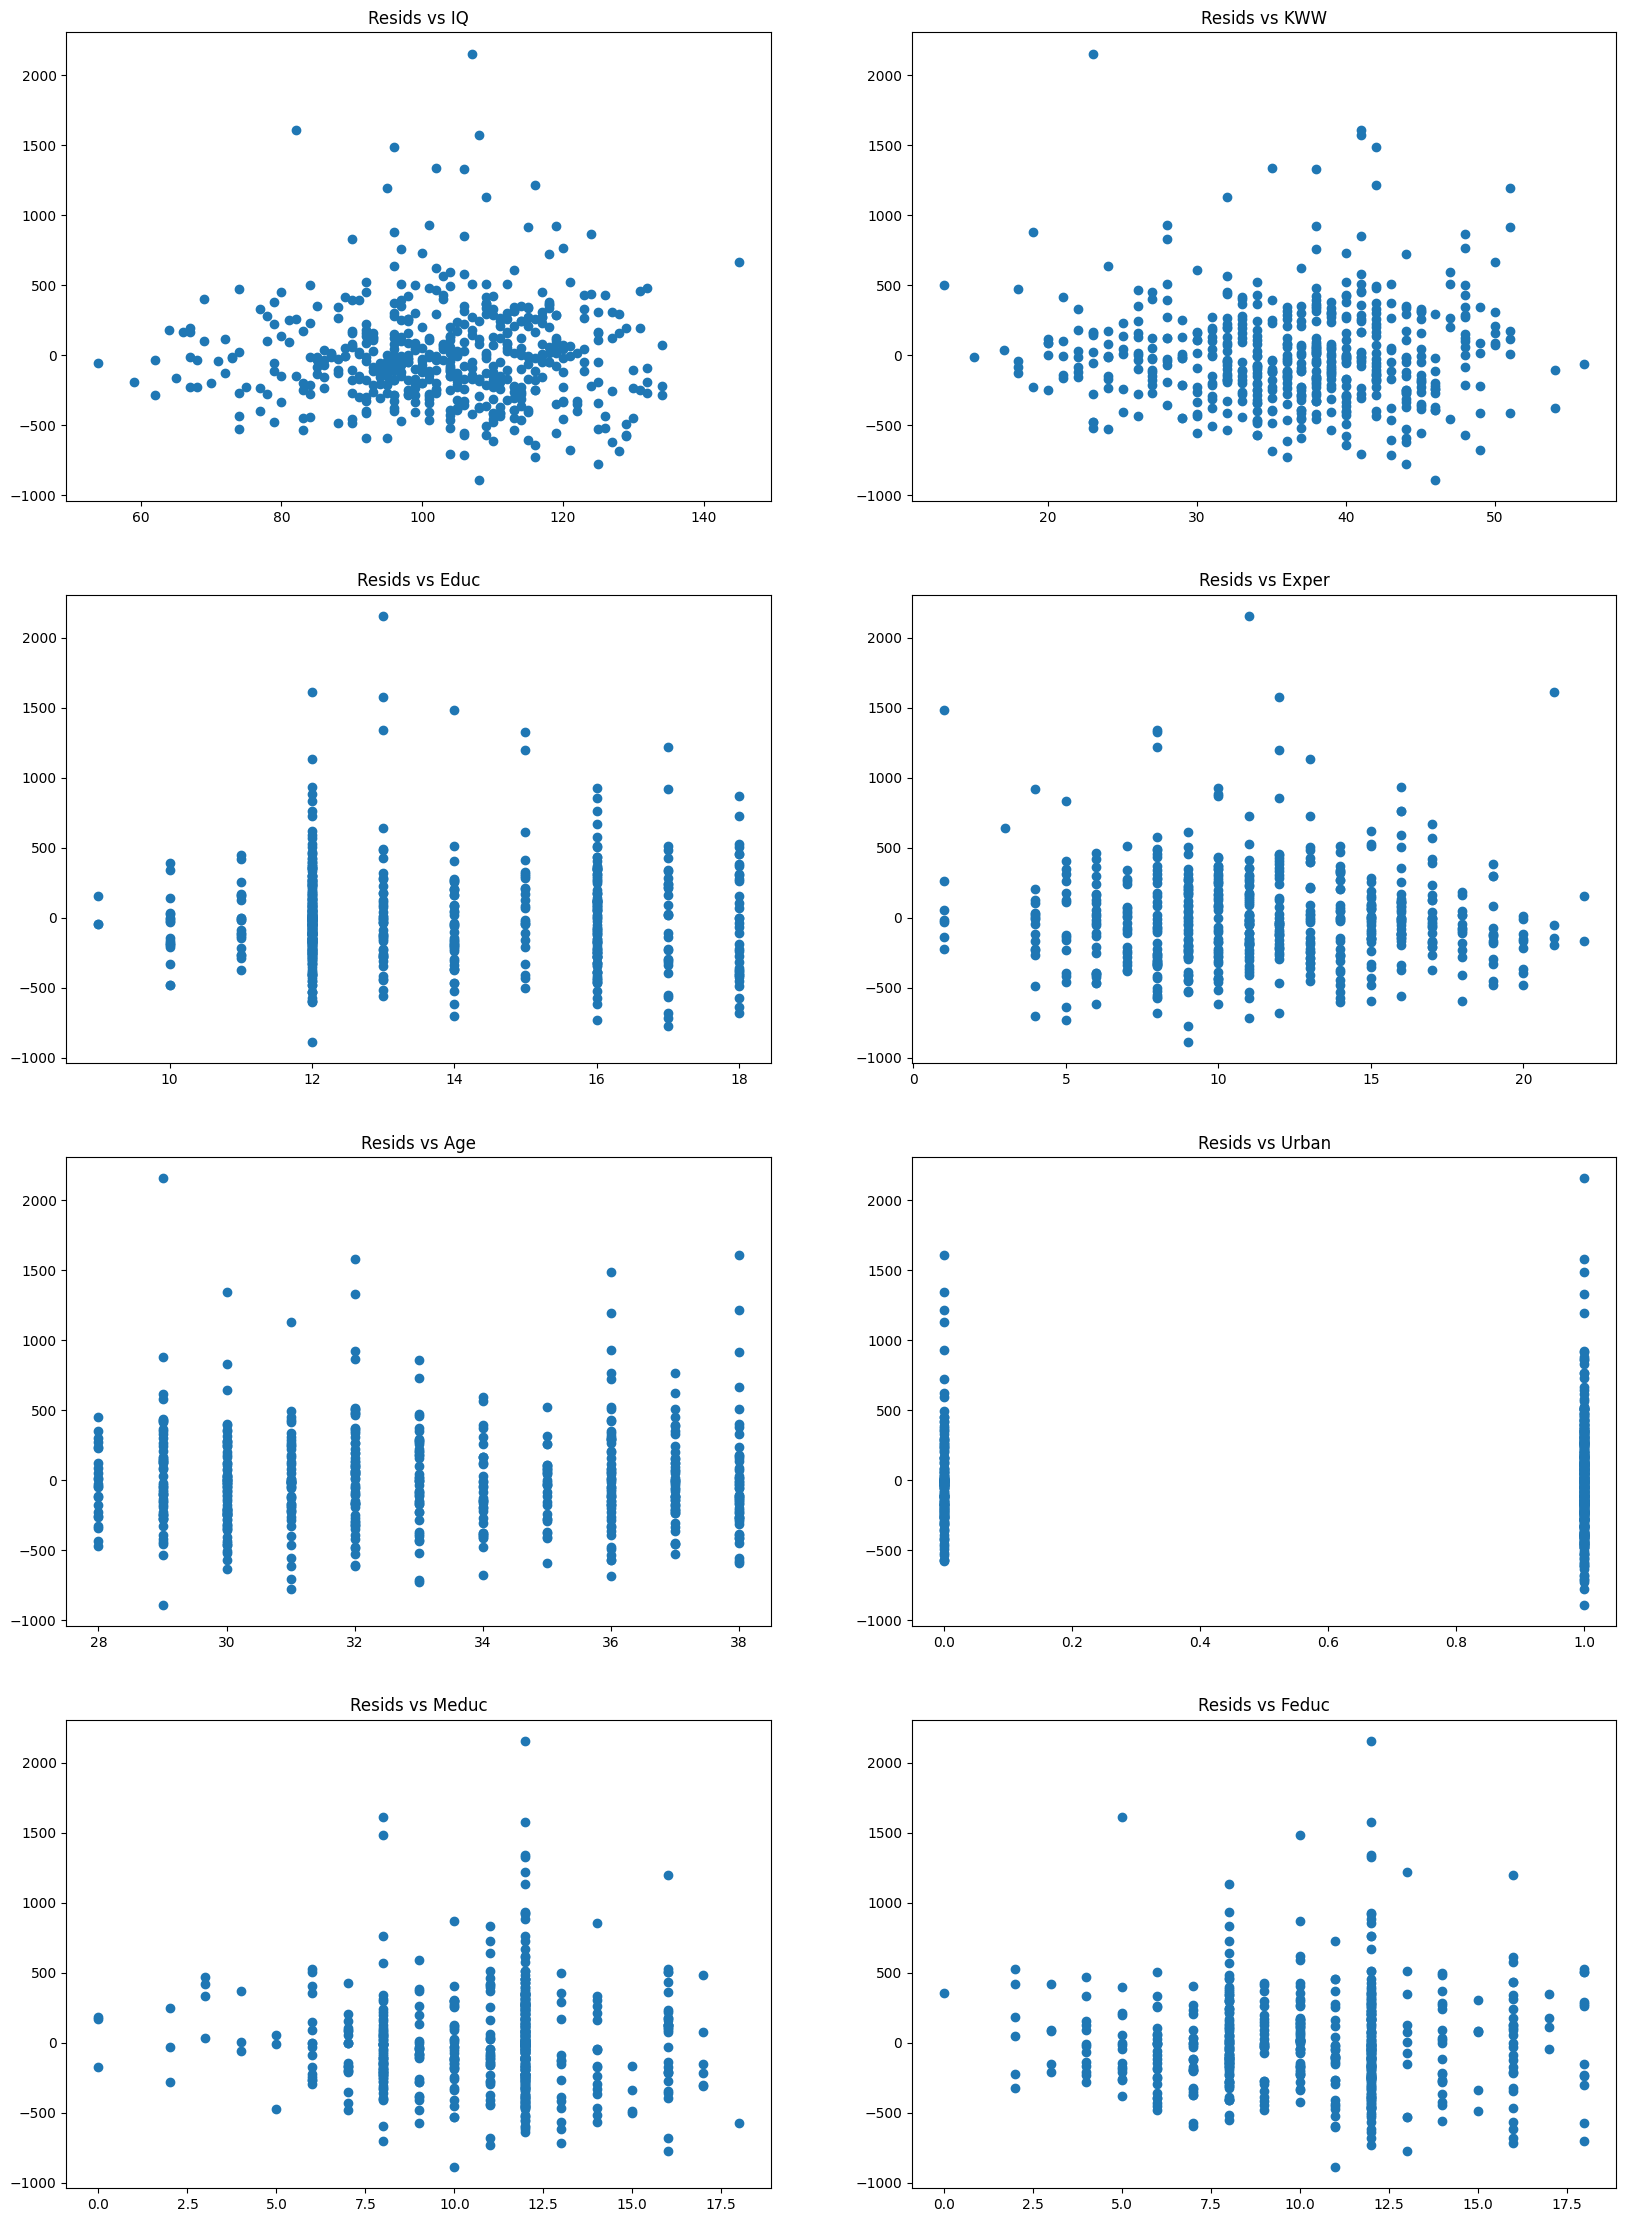

In [40]:
fig, ax = plt.subplots(4, 2, figsize=(20, 28))  # 8 plots = 4 rows, 2 columns

ax[0,0].scatter(train['IQ'], newresid)
ax[0,0].set_title("Resids vs IQ")

ax[0,1].scatter(train['KWW'], newresid)
ax[0,1].set_title("Resids vs KWW")

ax[1,0].scatter(train['educ'], newresid)
ax[1,0].set_title("Resids vs Educ")

ax[1,1].scatter(train['exper'], newresid)
ax[1,1].set_title("Resids vs Exper")

ax[2,0].scatter(train['age'], newresid)
ax[2,0].set_title("Resids vs Age")

ax[2,1].scatter(train['urban'], newresid)
ax[2,1].set_title("Resids vs Urban")

ax[3,0].scatter(train['meduc'], newresid)
ax[3,0].set_title("Resids vs Meduc")

ax[3,1].scatter(train['feduc'], newresid)
ax[3,1].set_title("Resids vs Feduc")

plt.show()


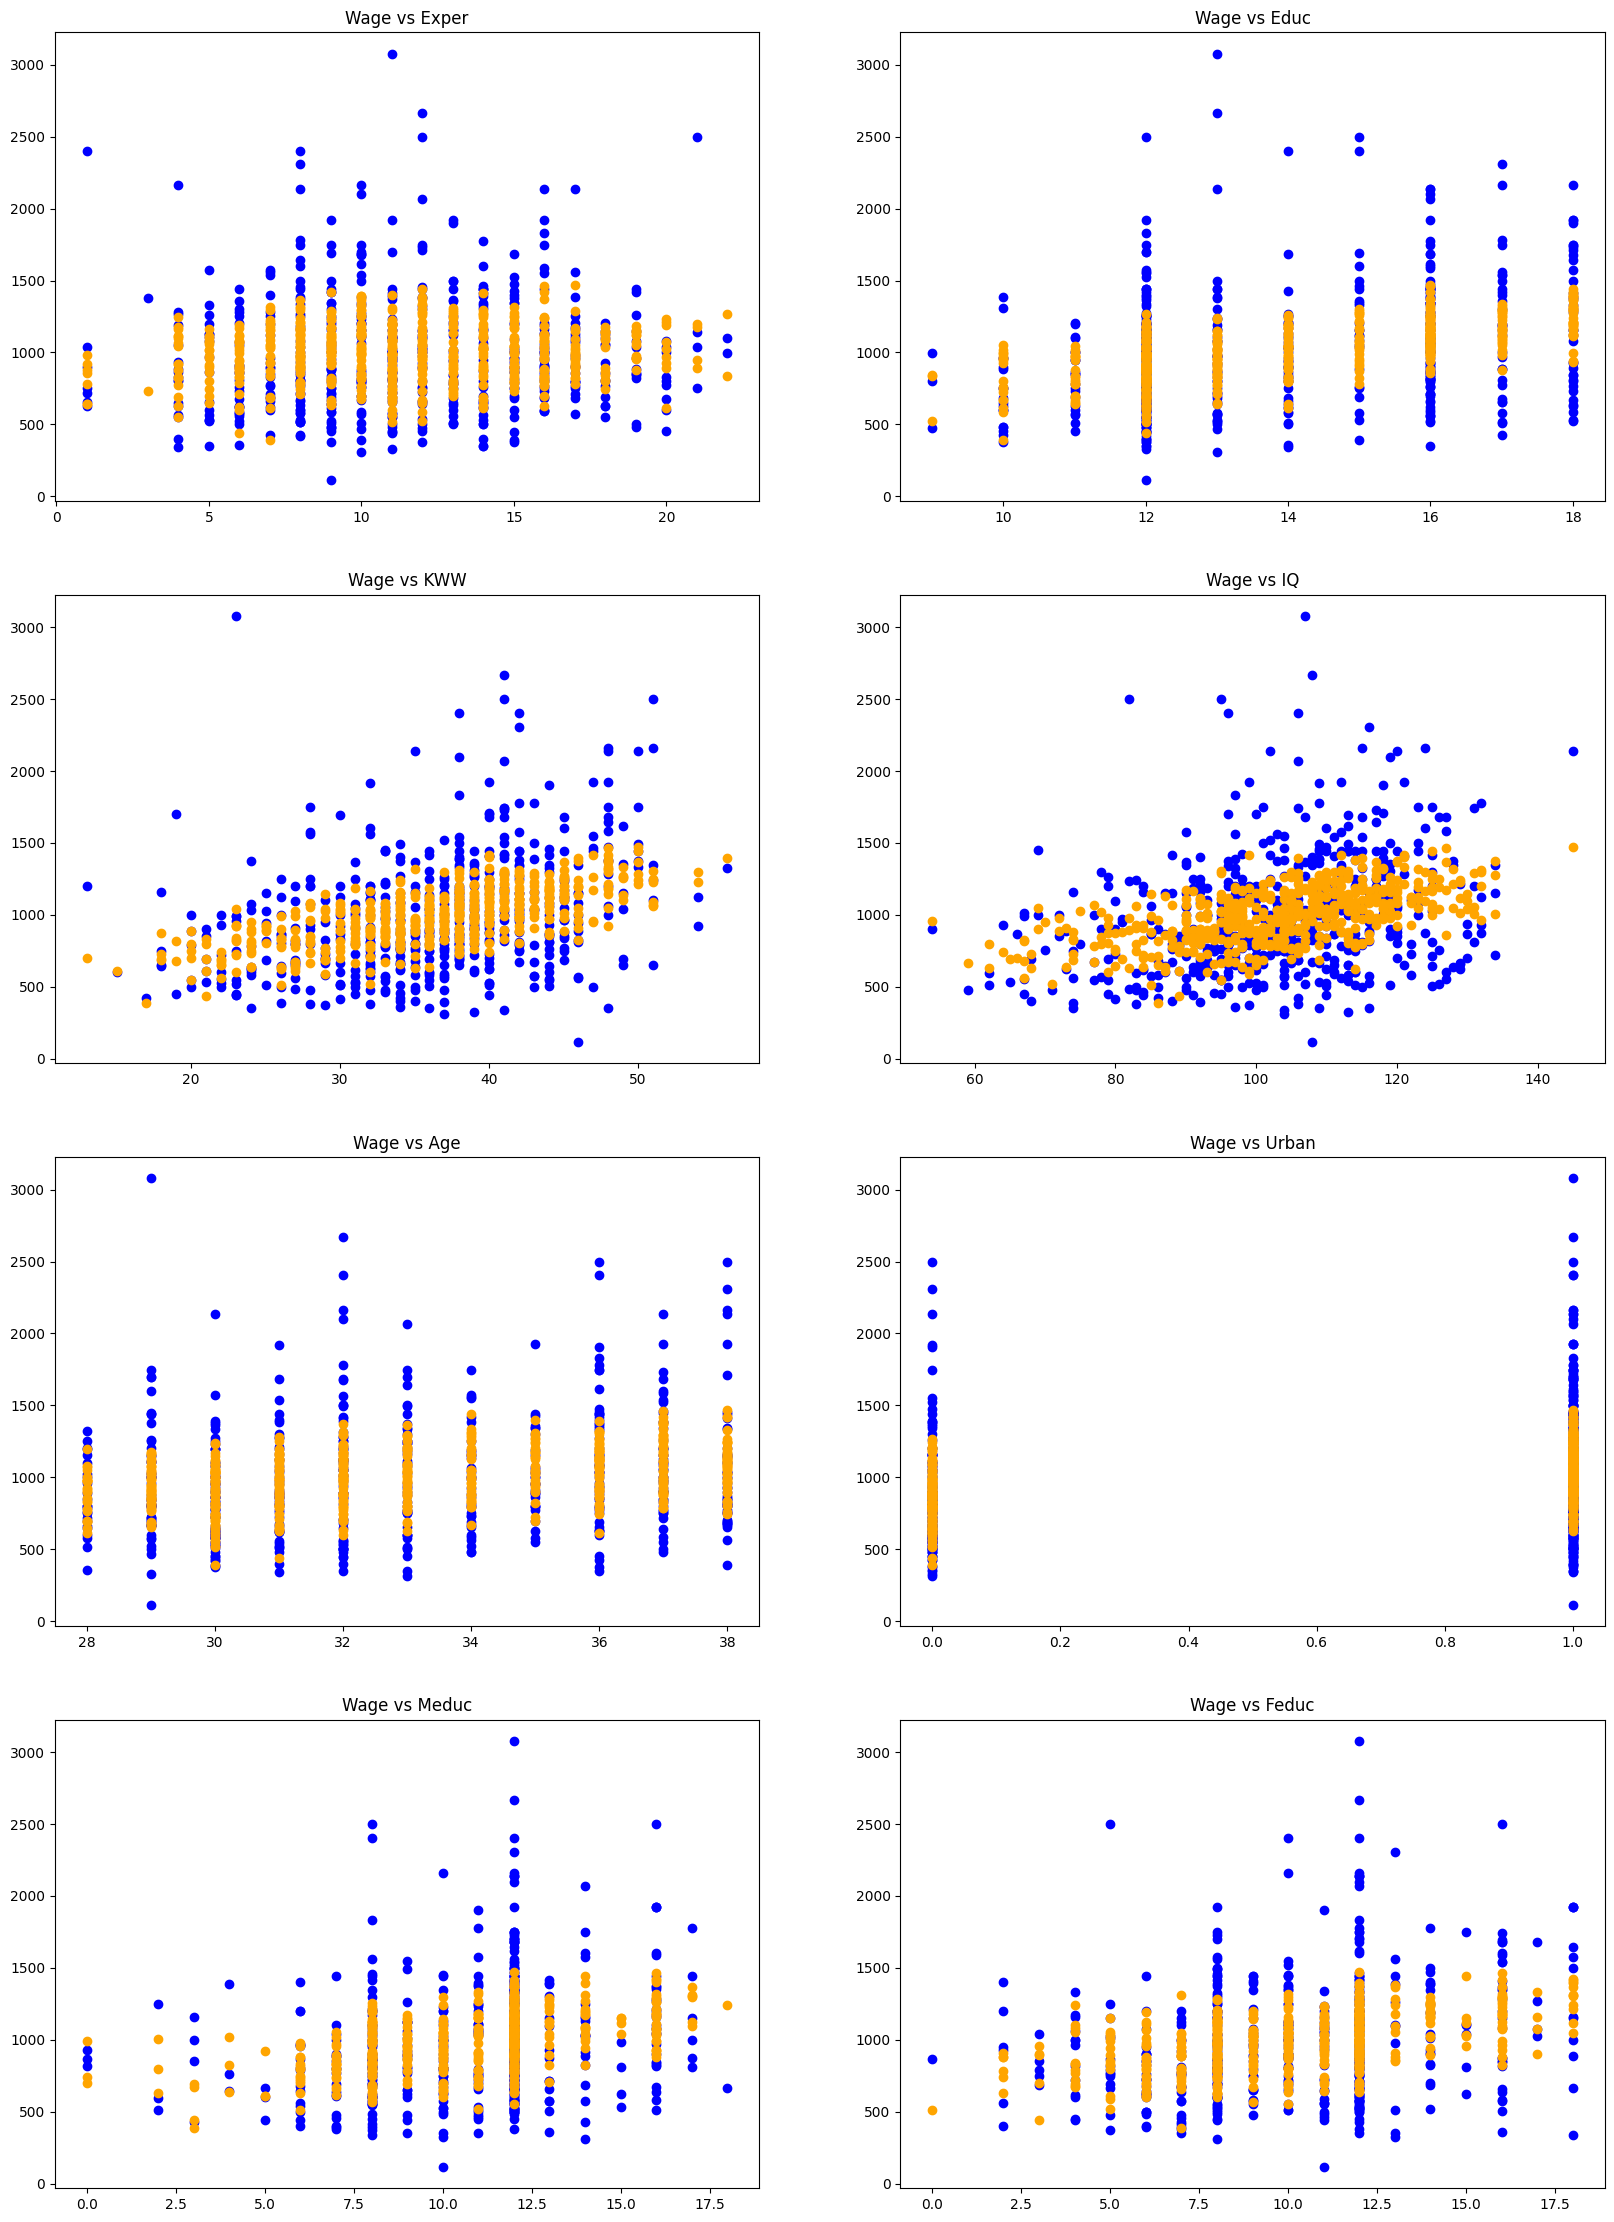

In [41]:

fig, ax = plt.subplots(4, 2, figsize=(20, 28))

ax[0,0].scatter(train['exper'], train['wage'], c='blue')
ax[0,0].scatter(train['exper'], newfit, c='orange')
ax[0,0].set_title("Wage vs Exper")

ax[0,1].scatter(train['educ'], train['wage'], c='blue')
ax[0,1].scatter(train['educ'], newfit, c='orange')
ax[0,1].set_title("Wage vs Educ")

ax[1,0].scatter(train['KWW'], train['wage'], c='blue')
ax[1,0].scatter(train['KWW'], newfit, c='orange')
ax[1,0].set_title("Wage vs KWW")

ax[1,1].scatter(train['IQ'], train['wage'], c='blue')
ax[1,1].scatter(train['IQ'], newfit, c='orange')
ax[1,1].set_title("Wage vs IQ")

ax[2,0].scatter(train['age'], train['wage'], c='blue')
ax[2,0].scatter(train['age'], newfit, c='orange')
ax[2,0].set_title("Wage vs Age")

ax[2,1].scatter(train['urban'], train['wage'], c='blue')
ax[2,1].scatter(train['urban'], newfit, c='orange')
ax[2,1].set_title("Wage vs Urban")

ax[3,0].scatter(train['meduc'], train['wage'], c='blue')
ax[3,0].scatter(train['meduc'], newfit, c='orange')
ax[3,0].set_title("Wage vs Meduc")

ax[3,1].scatter(train['feduc'], train['wage'], c='blue')
ax[3,1].scatter(train['feduc'], newfit, c='orange')
ax[3,1].set_title("Wage vs Feduc")


plt.show()


The original reduced multiple linear regression (MLR) model was estimated as:

$$
\hat{Wage} = -264.39 + 74.15 \times \text{educ} + 21.23 \times \text{exper}
$$

The 95% confidence intervals for the two slopes are:
- **educ**: (58.04, 90.26)
- **exper**: (12.74, 29.72)

---

The new MLR model (with KWW, IQ, age, urban, meduc, feduc included) is estimated as:

$$
\hat{Wage} = -716.16 + 7.27 \times \text{KWW} +  2.47 \times 
text{IQ} + 6.69 \times \text{age} + 163.41 \times \text{urban} + 5.70 \times \text{meduc} + 12.61 \times \text{feduc} + 35.88 \times \text{educ} + 14.90 \times \text{exper}
$$

The 95% confidence intervals for the three slopes are:
- **IQ**: (-0.219, 5.169)
- **KWW**: (1.92, 12.62)
- **age**: (-6.95, 20.32)
- **urban**: (93.29, 233.53)
- **meduc**: (-8.41, 19.81)
- **feduc**: (0.42, 24.80)
- **educ**: (15.60, 56.17)
- **exper**: (4.87, 24.93)

---

The estimated effect of **educ** in the three-variable MLR has dropped below the 95% confidence interval from the two-variable MLR. This suggests that **all chosen suspected variables were causing omitted variable bias (OVB)** in the original estimate of education’s effect on wage.

The estimated effect of **exper** has become slightly more negative in the three-variable model. However, the 95% confidence intervals from both models overlap substantially. This implies the difference in estimates could be due to **estimation error rather than OVB**.

However, the p-value could be examined to look at the effects of these variables. The standouts are p-values of 0.072, 0.336, 0.428 for IQ, age, and meduc, respectively, suggesting that we cannot reject the hypothesis that they do not affect wage. feduc is also only mildly smaller than the chosen alpha (0.043 < 0.05), making its impact questionable. Nevertheless, all other variables have p-value of near 0, indicating that they might be the cause for OVB here. 

In summary, while the inclusion of all chosen suspected variables reveal likely OVB in the estimate of **educ**, the **large standard errors** make it difficult to precisely quantify how much bias was introduced — or if the bias in **exper** was meaningful at all.


### **b. Test for relationships between wage, exper, educ**

### Correlation matrix 

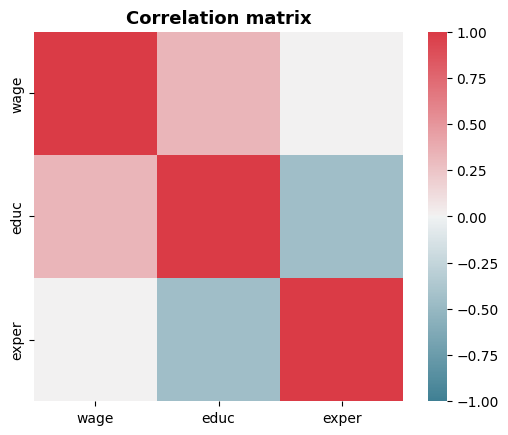

In [42]:
fig_wee, ax_wee = plt.subplots()
variables = ['wage', 'educ', 'exper']
cmap = sns.diverging_palette(220, 10, as_cmap=True)

sns.heatmap(data[variables].corr(), vmax=1, vmin=-1, center=0, square=True, ax=ax_wee, cmap=cmap)
ax_wee.set_title('Correlation matrix', fontweight='bold', fontsize=13)


plt.show()

In [43]:
train[['educ', 'exper', 'wage']].corr().round(2)


,educ,exper,wage
educ,1.00,-0.44,0.31
exper,-0.44,1.00,0.04
wage,0.31,0.04,1.00


There are some clear correlations between wage and educ, wage and exper. For wage and educ, they have a positive correlation with $r = 0.31$, while that between wage and exper is $0.04$ meaning little to no real impact. Interestingly, exper and educ are highly correlated, with $r = -0.44$, making it the highest negative correlation between 2 variables. 

### OLS between wage and exper, wage and educ

In [44]:
model_task3_educ = smf.ols(formula='wage ~ educ', data=train) 
reg_task3_educ = model_task3_educ.fit()
reg_task3_educ.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   wage   R-squared:                       0.096
Model:                            OLS   Adj. R-squared:                  0.094
Method:                 Least Squares   F-statistic:                     56.30
Date:                Tue, 27 May 2025   Prob (F-statistic):           2.65e-13
Time:                        17:40:21   Log-Likelihood:                -3920.0
No. Observations:                 531   AIC:                             7844.
Df Residuals:                     529   BIC:                             7852.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    220.2444    104.714      2.103      0.036      14.538     425.951
educ          56.4936      7.529      7.503      0.000      41.703      71.285
==============================================================================
Omnibus:                      116.748   Durbin-Watson:                   1.869
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              294.467
Skew:                           1.103   Prob(JB):                     1.14e-64
Kurtosis:                       5.905   Cond. No.                         86.6
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

The $R^2$ and $R^2_{adj}$ for predicting wage using years of education is 0.096 and 0.094 respectively, suggesting that only 1% of the variation in wage can be explained using only years of education. This is a quite low number, but the extremely low of p-value for educ suggests that educ is indeed necessary in predicting wage.

In [45]:
model_task3_exper = smf.ols(formula='wage ~ exper', data=train) 
reg_task3_exper = model_task3_exper.fit()
reg_task3_exper.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   wage   R-squared:                       0.002
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                    0.9591
Date:                Tue, 27 May 2025   Prob (F-statistic):              0.328
Time:                        17:40:21   Log-Likelihood:                -3946.3
No. Observations:                 531   AIC:                             7897.
Df Residuals:                     529   BIC:                             7905.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    949.0028     50.811     18.677      0.000     849.187    1048.818
exper          4.0849      4.171      0.979      0.328      -4.109      12.279
==============================================================================
Omnibus:                      114.554   Durbin-Watson:                   1.903
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              239.149
Skew:                           1.165   Prob(JB):                     1.17e-52
Kurtosis:                       5.319   Cond. No.                         35.0
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In contrast to educ, exper seems to have no relationship with wage. The $R^2$ and $R^2_{adj}$ for OLS between wage and exper is only 0.002 and -0.000, which is very low and is not statistically significant. The p-value of exper further confirms this as it stands at 0.328. 

Overall, we can conclude that at significance level of 0.05, there is a relationship between wage and years of education but none between wage and years of experience. However, we realize that this could be due to the the large amount of data dropped during the data cleaning process, causing data distortion. It is also noteworthy that while using the predictive models may rule out years of experience as statistically insignificant, exper remains one of the most important factor that can cause wage changes (intuitively speaking).

### **c. LSAs discussions**

### **d. Multicollinearity discussion**

In [46]:
#calculate VIFs for predictors
features=train[['educ','exper','IQ','KWW', 'age', 'urban', 'meduc', 'feduc']]
features=sm.add_constant(features)
from statsmodels.stats.outliers_influence import variance_inflation_factor
vif=[]
for i in range(1,features.shape[1]):
    vif_value=variance_inflation_factor(features.values,i)
    vif.append(vif_value)
    print(f"VIF for {features.columns[i]}: {vif_value:.3f}")
average_vif=sum(vif)/len(vif)
print(f"Average VIF: {average_vif:.3f}")

VIF for educ: 2.150
VIF for exper: 1.892
VIF for IQ: 1.637
VIF for KWW: 1.692
VIF for age: 1.854
VIF for urban: 1.024
VIF for meduc: 1.615
VIF for feduc: 1.675
Average VIF: 1.692


The variance inflation can be measured by the $R^2$ in the regression of one regressor on the other. Both equal to $\frac{1}{1-r^2}$, where $r$ is the correlation between two variables, as calculated above, equal around 1. 

The threshold for these are usually set at 5, and all of the calculated VIFs are well below that number, indicating no perfect multicollinearity in this model.

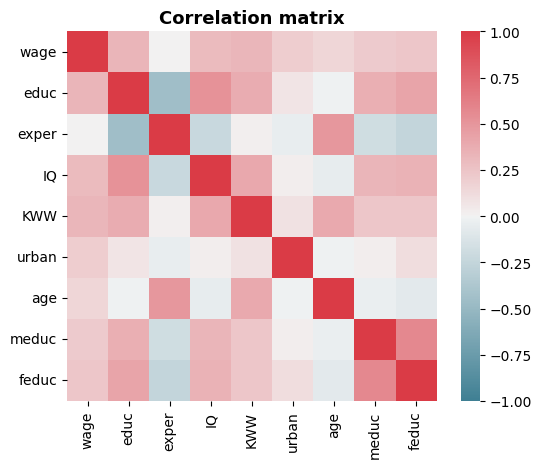

In [47]:
fig_ovb, ax_ovb = plt.subplots()
variables = ['wage', 'educ', 'exper', 'IQ', 'KWW', 'urban', 'age', 'meduc', 'feduc']
cmap = sns.diverging_palette(220, 10, as_cmap=True)

sns.heatmap(data[variables].corr(), vmax=1, vmin=-1, center=0, square=True, ax=ax_ovb, cmap=cmap)
ax_ovb.set_title('Correlation matrix', fontweight='bold', fontsize=13)


plt.show()

The correlation matrix between these variables, however, is quite interesting as they show some significant correlation between variables such as age vs exper.

# **Task 4: Model and Variable selection**